=== Column picks ===
CE: distance column -> Distance (cm)
WC: distance column -> Distance (cm)
WE: distance column -> Distance (cm)
Pc: time column -> time | pressure column -> F_pressure_kPa

=== Common overlap ===
start: 2022-10-15T00:00:00+00:00
end  : 2025-08-24T00:00:00+00:00
days : 1045

==== CE fit: L = a*Pc + b*sin + c*cos + d  (N=1045) ====
a (Pc)       : -6.64359174
b (sin)      : -0.90477789
c (cos)      : 1.53855872
d (intercept): 164214.20608483
season amp   : 1.78488 cm  (ptp=3.56975 cm)


==== WC fit: L = a*Pc + b*sin + c*cos + d  (N=1045) ====
a (Pc)       : -0.89834565
b (sin)      : -0.58662874
c (cos)      : 1.36268538
d (intercept): 176562.17513839
season amp   : 1.48359 cm  (ptp=2.96718 cm)


==== WE fit: L = a*Pc + b*sin + c*cos + d  (N=1045) ====
a (Pc)       : -7.17330233
b (sin)      : -2.76791406
c (cos)      : 2.92750198
d (intercept): 326024.28296249
season amp   : 4.02885 cm  (ptp=8.05770 cm)



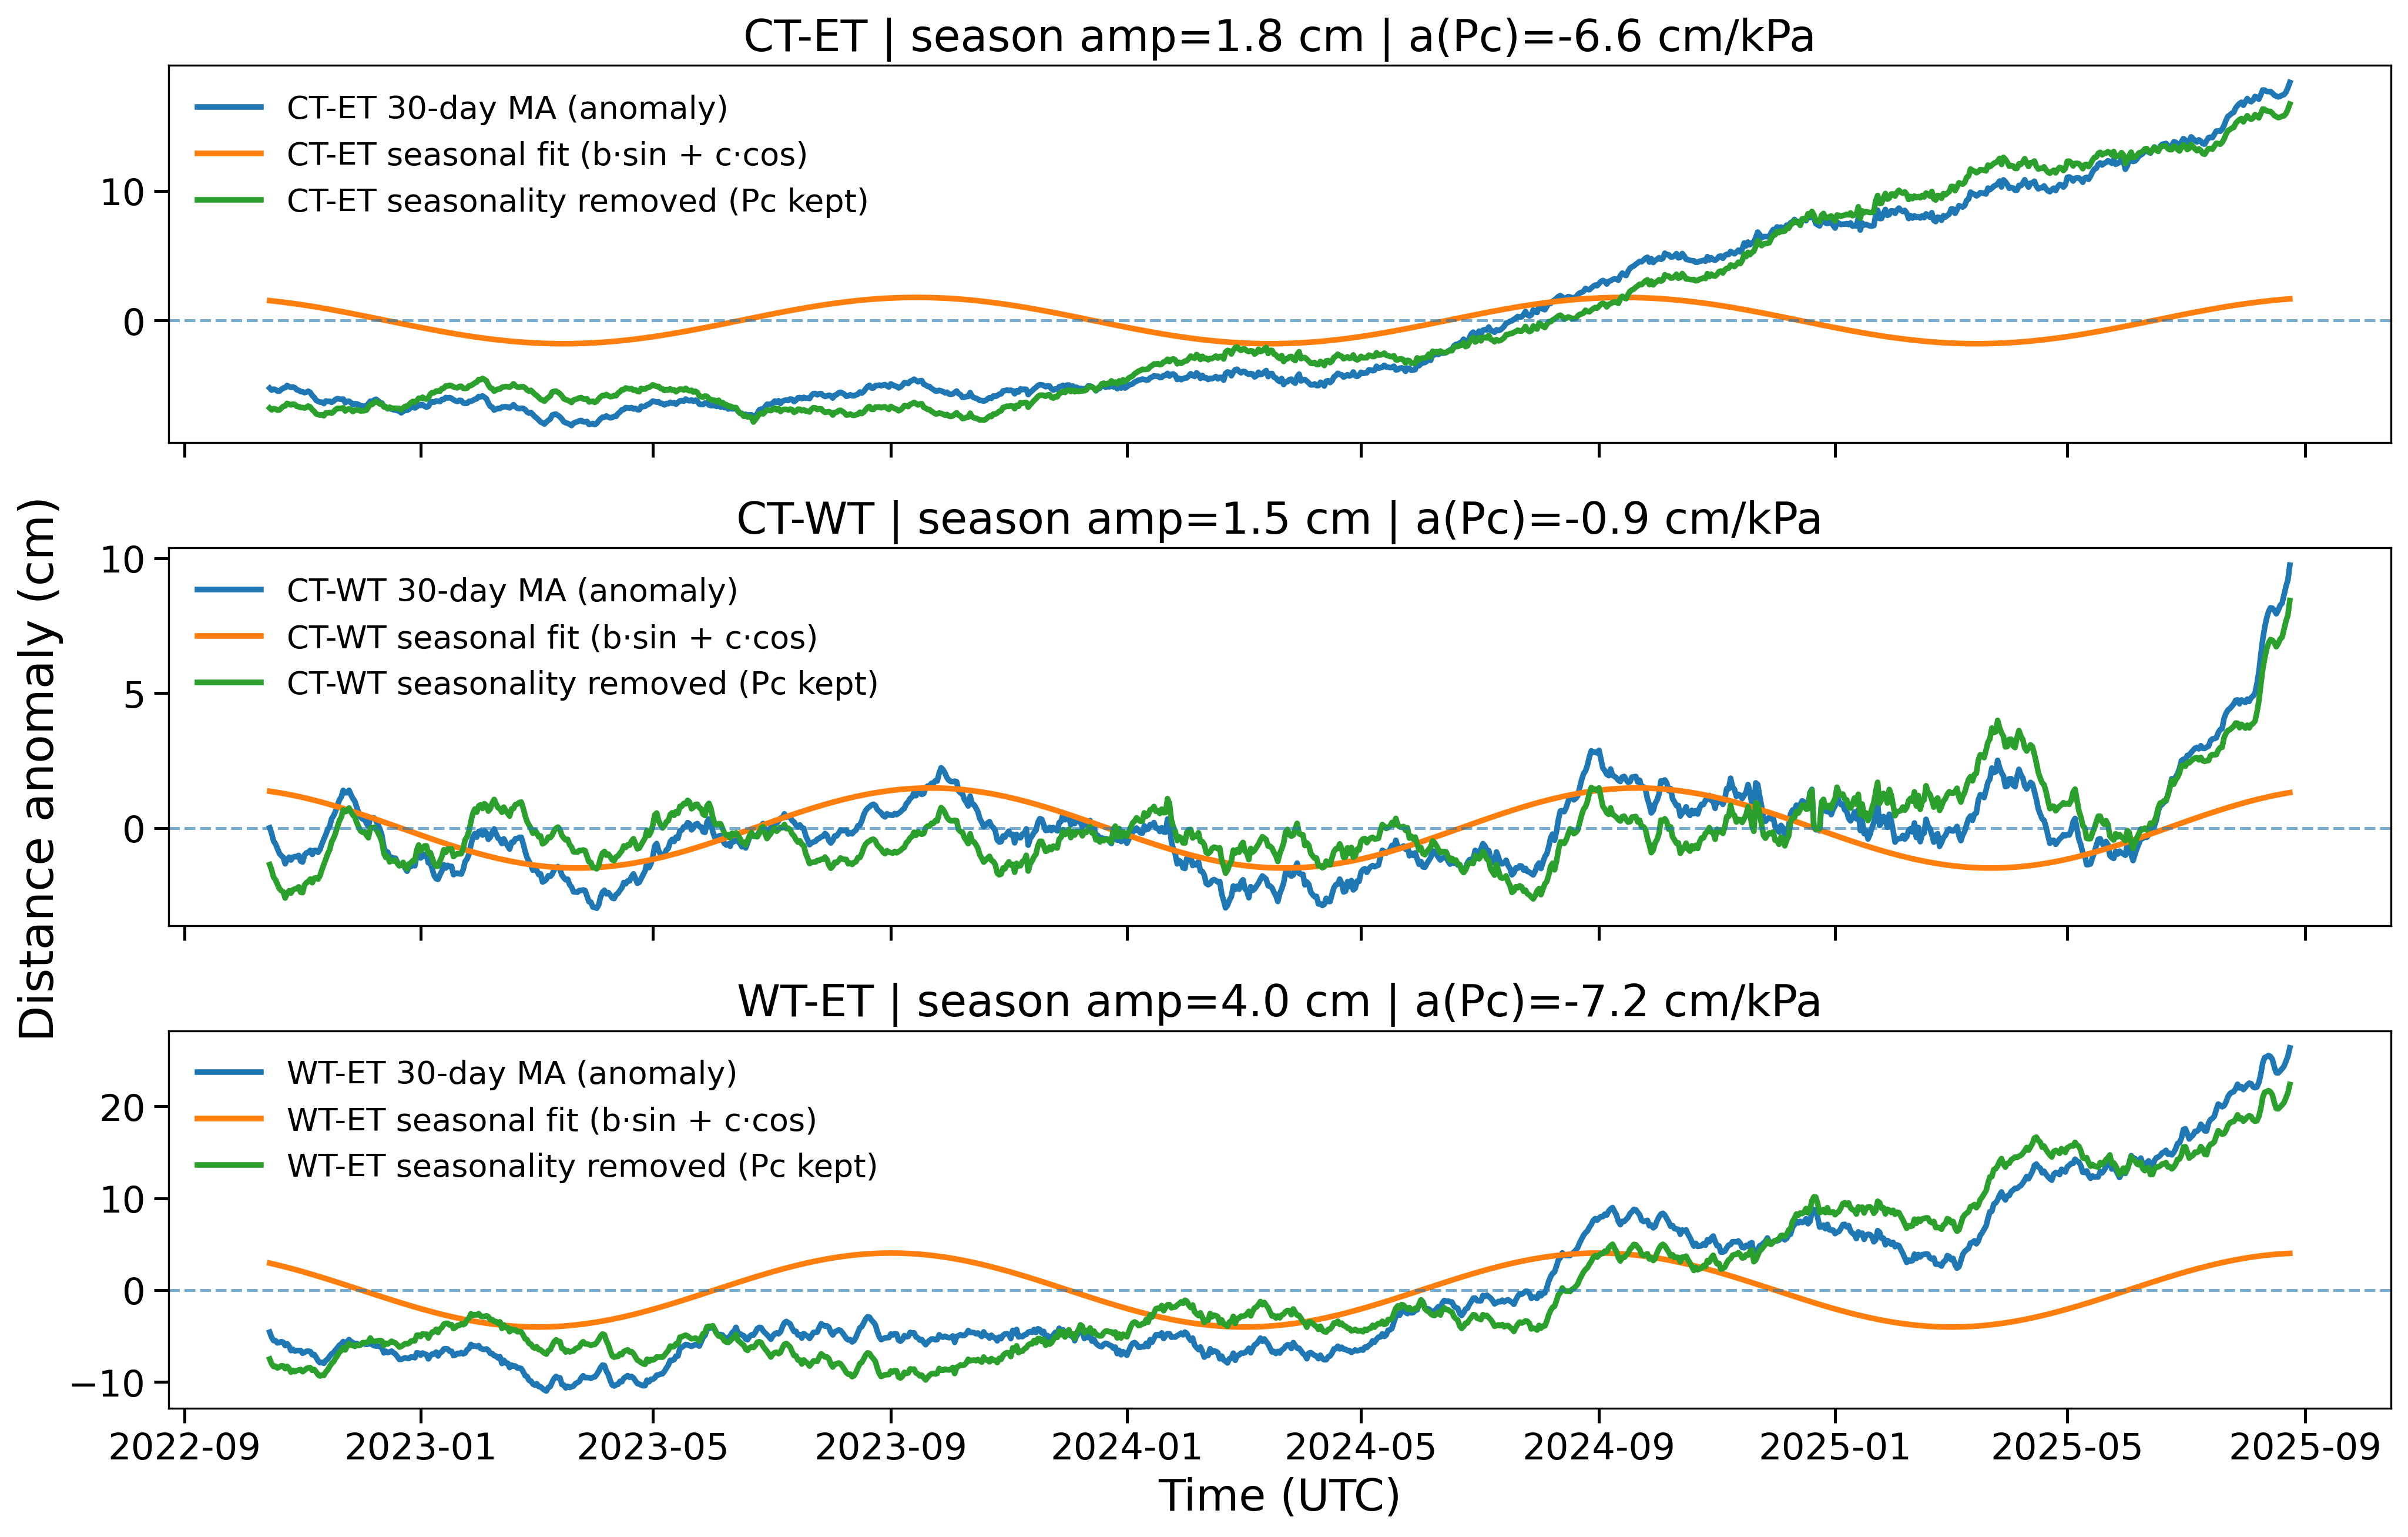

'baselines_fit_outputs.csv'

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CE_FILE = "CE_distance_longer.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pf_drifcor.csv"

DROP_DAYS = 30
MA_DAYS = 30

T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

def _to_utc_datetime(s):
    return pd.to_datetime(s, utc=True, errors="coerce")

def pick_distance_column(df, name):
    # common candidates
    candidates = [
        "Distance (cm)",
        "Moving Average (cm)",
        "distance_cm",
        "distance",
        "Distance",
        "Moving Average",
        "Baseline (cm)",
    ]
    for c in candidates:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            return c

    # otherwise pick the numeric column with largest variance (excluding obvious IDs)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        raise ValueError(f"{name}: no numeric columns found to use as distance.")
    # avoid constant columns
    best = None
    best_var = -np.inf
    for c in num_cols:
        v = float(np.nanvar(df[c].to_numpy()))
        if v > best_var:
            best_var = v
            best = c
    return best

def load_baseline_daily_ma30(path, name, drop_days=DROP_DAYS, ma_days=MA_DAYS):
    df = pd.read_csv(path)
    if "Record Time" not in df.columns:
        raise ValueError(f"{name}: expected a 'Record Time' column in {path}")
    df["Record Time"] = _to_utc_datetime(df["Record Time"])
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time").copy()

    dist_col = pick_distance_column(df, name)

    # Drop first DROP_DAYS from baseline's own start
    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=drop_days))].copy()

    daily = df.set_index("Record Time")[dist_col].resample("1D").mean()

    # 30-day moving average on daily series
    ma30 = daily.rolling(window=ma_days, min_periods=max(5, ma_days // 2)).mean()
    ma30.name = name
    return ma30, dist_col

def load_pc_daily(path):
    df = pd.read_csv(path)
    time_col = "Record Time" if "Record Time" in df.columns else ("time" if "time" in df.columns else None)
    if time_col is None:
        raise ValueError(f"PC file must contain 'Record Time' or 'time' column: {path}")
    df[time_col] = _to_utc_datetime(df[time_col])
    df = df.dropna(subset=[time_col]).sort_values(time_col).copy()

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError("PC file has no numeric columns to use as Pc.")
    # prefer common pressure names if present
    pref = ["Pf", "Pc", "Pressure", "pressure", "Value", "value"]
    pc_col = None
    for p in pref:
        if p in df.columns and pd.api.types.is_numeric_dtype(df[p]):
            pc_col = p
            break
    if pc_col is None:
        pc_col = numeric_cols[0]

    pc = df.set_index(time_col)[pc_col].resample("1D").mean()
    pc.name = "Pc"
    return pc, pc_col, time_col

def fit_model_L_aPc_bsin_ccos_d(y_series, pc_series, t0_common):
    tmp = pd.concat([y_series, pc_series], axis=1).dropna()
    y = tmp.iloc[:, 0].to_numpy()
    pc = tmp.iloc[:, 1].to_numpy()

    t_days = (tmp.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([pc, sin_t, cos_t, np.ones_like(t_days)])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season = b * sin_t + c * cos_t
    deseason = y - season

    amp = float(np.sqrt(b * b + c * c))
    diag = {
        "a_Pc": float(a),
        "b_sin": float(b),
        "c_cos": float(c),
        "d_intercept": float(d),
        "season_amp_cm": amp,
        "season_ptp_cm": 2.0 * amp,
        "n_obs": int(len(y)),
    }

    idx = tmp.index
    season_s = pd.Series(season, index=idx, name=y_series.name + "_season")
    deseason_s = pd.Series(deseason, index=idx, name=y_series.name + "_deseason")
    return season_s, deseason_s, diag

# -----------------------------
# Run
# -----------------------------
baseline_series = {}
dist_cols = {}
for name, path in BASELINES:
    s, dist_col = load_baseline_daily_ma30(path, name)
    baseline_series[name] = s
    dist_cols[name] = dist_col

pc, pc_col, pc_time_col = load_pc_daily(PC_FILE)

df_all = pd.concat([baseline_series[n] for n, _ in BASELINES] + [pc], axis=1).dropna()
df = df_all[[n for n, _ in BASELINES]]
pc_aligned = df_all["Pc"]

t0_common = df.index[0]

print("=== Column picks ===")
for n in [x[0] for x in BASELINES]:
    print(f"{n}: distance column -> {dist_cols[n]}")
print(f"Pc: time column -> {pc_time_col} | pressure column -> {pc_col}")

print("\n=== Common overlap ===")
print(f"start: {df.index[0].isoformat()}")
print(f"end  : {df.index[-1].isoformat()}")
print(f"days : {len(df)}")

season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)
diags = {}

for n in [x[0] for x in BASELINES]:
    s, yds, diag = fit_model_L_aPc_bsin_ccos_d(df[n], pc_aligned, t0_common)
    season[n] = s.reindex(df.index)
    deseason[n] = yds.reindex(df.index)
    diags[n] = diag

    print(
        f"\n==== {n} fit: L = a*Pc + b*sin + c*cos + d  (N={diag['n_obs']}) ====\n"
        f"a (Pc)       : {diag['a_Pc']:.8f}\n"
        f"b (sin)      : {diag['b_sin']:.8f}\n"
        f"c (cos)      : {diag['c_cos']:.8f}\n"
        f"d (intercept): {diag['d_intercept']:.8f}\n"
        f"season amp   : {diag['season_amp_cm']:.5f} cm  (ptp={diag['season_ptp_cm']:.5f} cm)\n"
    )


# ---- publication-style defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})

# Map baseline short names to publication labels
label_map = {
    "CE": "CT-ET",
    "WC": "CT-WT",
    "WE": "WT-ET",
}

# Plot anomalies for readability (remove mean of MA series per baseline)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), dpi=300, sharex=True)

for ax, n in zip(axes, [x[0] for x in BASELINES]):
    nlab = label_map.get(n, n)

    y0 = float(df[n].mean())

    ax.plot(df.index, df[n] - y0, lw=2.3, label=f"{nlab} 30-day MA (anomaly)")
    ax.plot(df.index, season[n], lw=2.3, label=f"{nlab} seasonal fit (b·sin + c·cos)")
    ax.plot(df.index, deseason[n] - y0, lw=2.3, label=f"{nlab} seasonality removed (Pc kept)")

    ax.set_title(
        f"{nlab} | season amp={diags[n]['season_amp_cm']:.1f} cm"
        f" | a(Pc)={diags[n]['a_Pc']:.2g} cm/kPa"
    )
    ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
    #ax.ylim(-12, 24)
    ax.tick_params(axis="both", which="major", length=6, width=1.2)
    ax.legend(frameon=False, loc="upper left")

axes[-1].set_xlabel("Time (UTC)")
fig.supylabel("Distance anomaly (cm)")
fig.tight_layout()
plt.show()

# Save combined outputs for convenience
out_df = pd.concat([df.add_suffix("_MA30"), pc_aligned.rename("Pc_daily")], axis=1)
for n in [x[0] for x in BASELINES]:
    out_df[f"{n}_season_fit"] = season[n]
    out_df[f"{n}_deseason_PcKept"] = deseason[n]

out_path = "baselines_fit_outputs.csv"
out_df.to_csv(out_path)
out_path

=== Column picks ===
CE: distance column -> Distance (cm)
WC: distance column -> Distance (cm)
WE: distance column -> Distance (cm)
Pc: time column -> time | pressure column -> F_pressure_kPa

=== Common overlap (TRUNCATED) ===
start: 2022-10-15T00:00:00+00:00
end  : 2025-08-09T00:00:00+00:00
days : 1030
END_DATE target: 2025-08-09T00:00:00+00:00

==== CE fit: L = a*Pc + b*sin + c*cos + d  (N=1030) ====
a (Pc)       : -6.60739959
b (sin)      : -0.87705929
c (cos)      : 1.50546212
d (intercept): 164214.18423438
season amp   : 1.74231 cm  (ptp=3.48462 cm)


==== WC fit: L = a*Pc + b*sin + c*cos + d  (N=1030) ====
a (Pc)       : -0.74668077
b (sin)      : -0.47348811
c (cos)      : 1.22182935
d (intercept): 176562.08431600
season amp   : 1.31037 cm  (ptp=2.62073 cm)


==== WE fit: L = a*Pc + b*sin + c*cos + d  (N=1030) ====
a (Pc)       : -7.02705161
b (sin)      : -2.65727053
c (cos)      : 2.79280110
d (intercept): 326024.19501281
season amp   : 3.85497 cm  (ptp=7.70995 cm)


=== EXTE

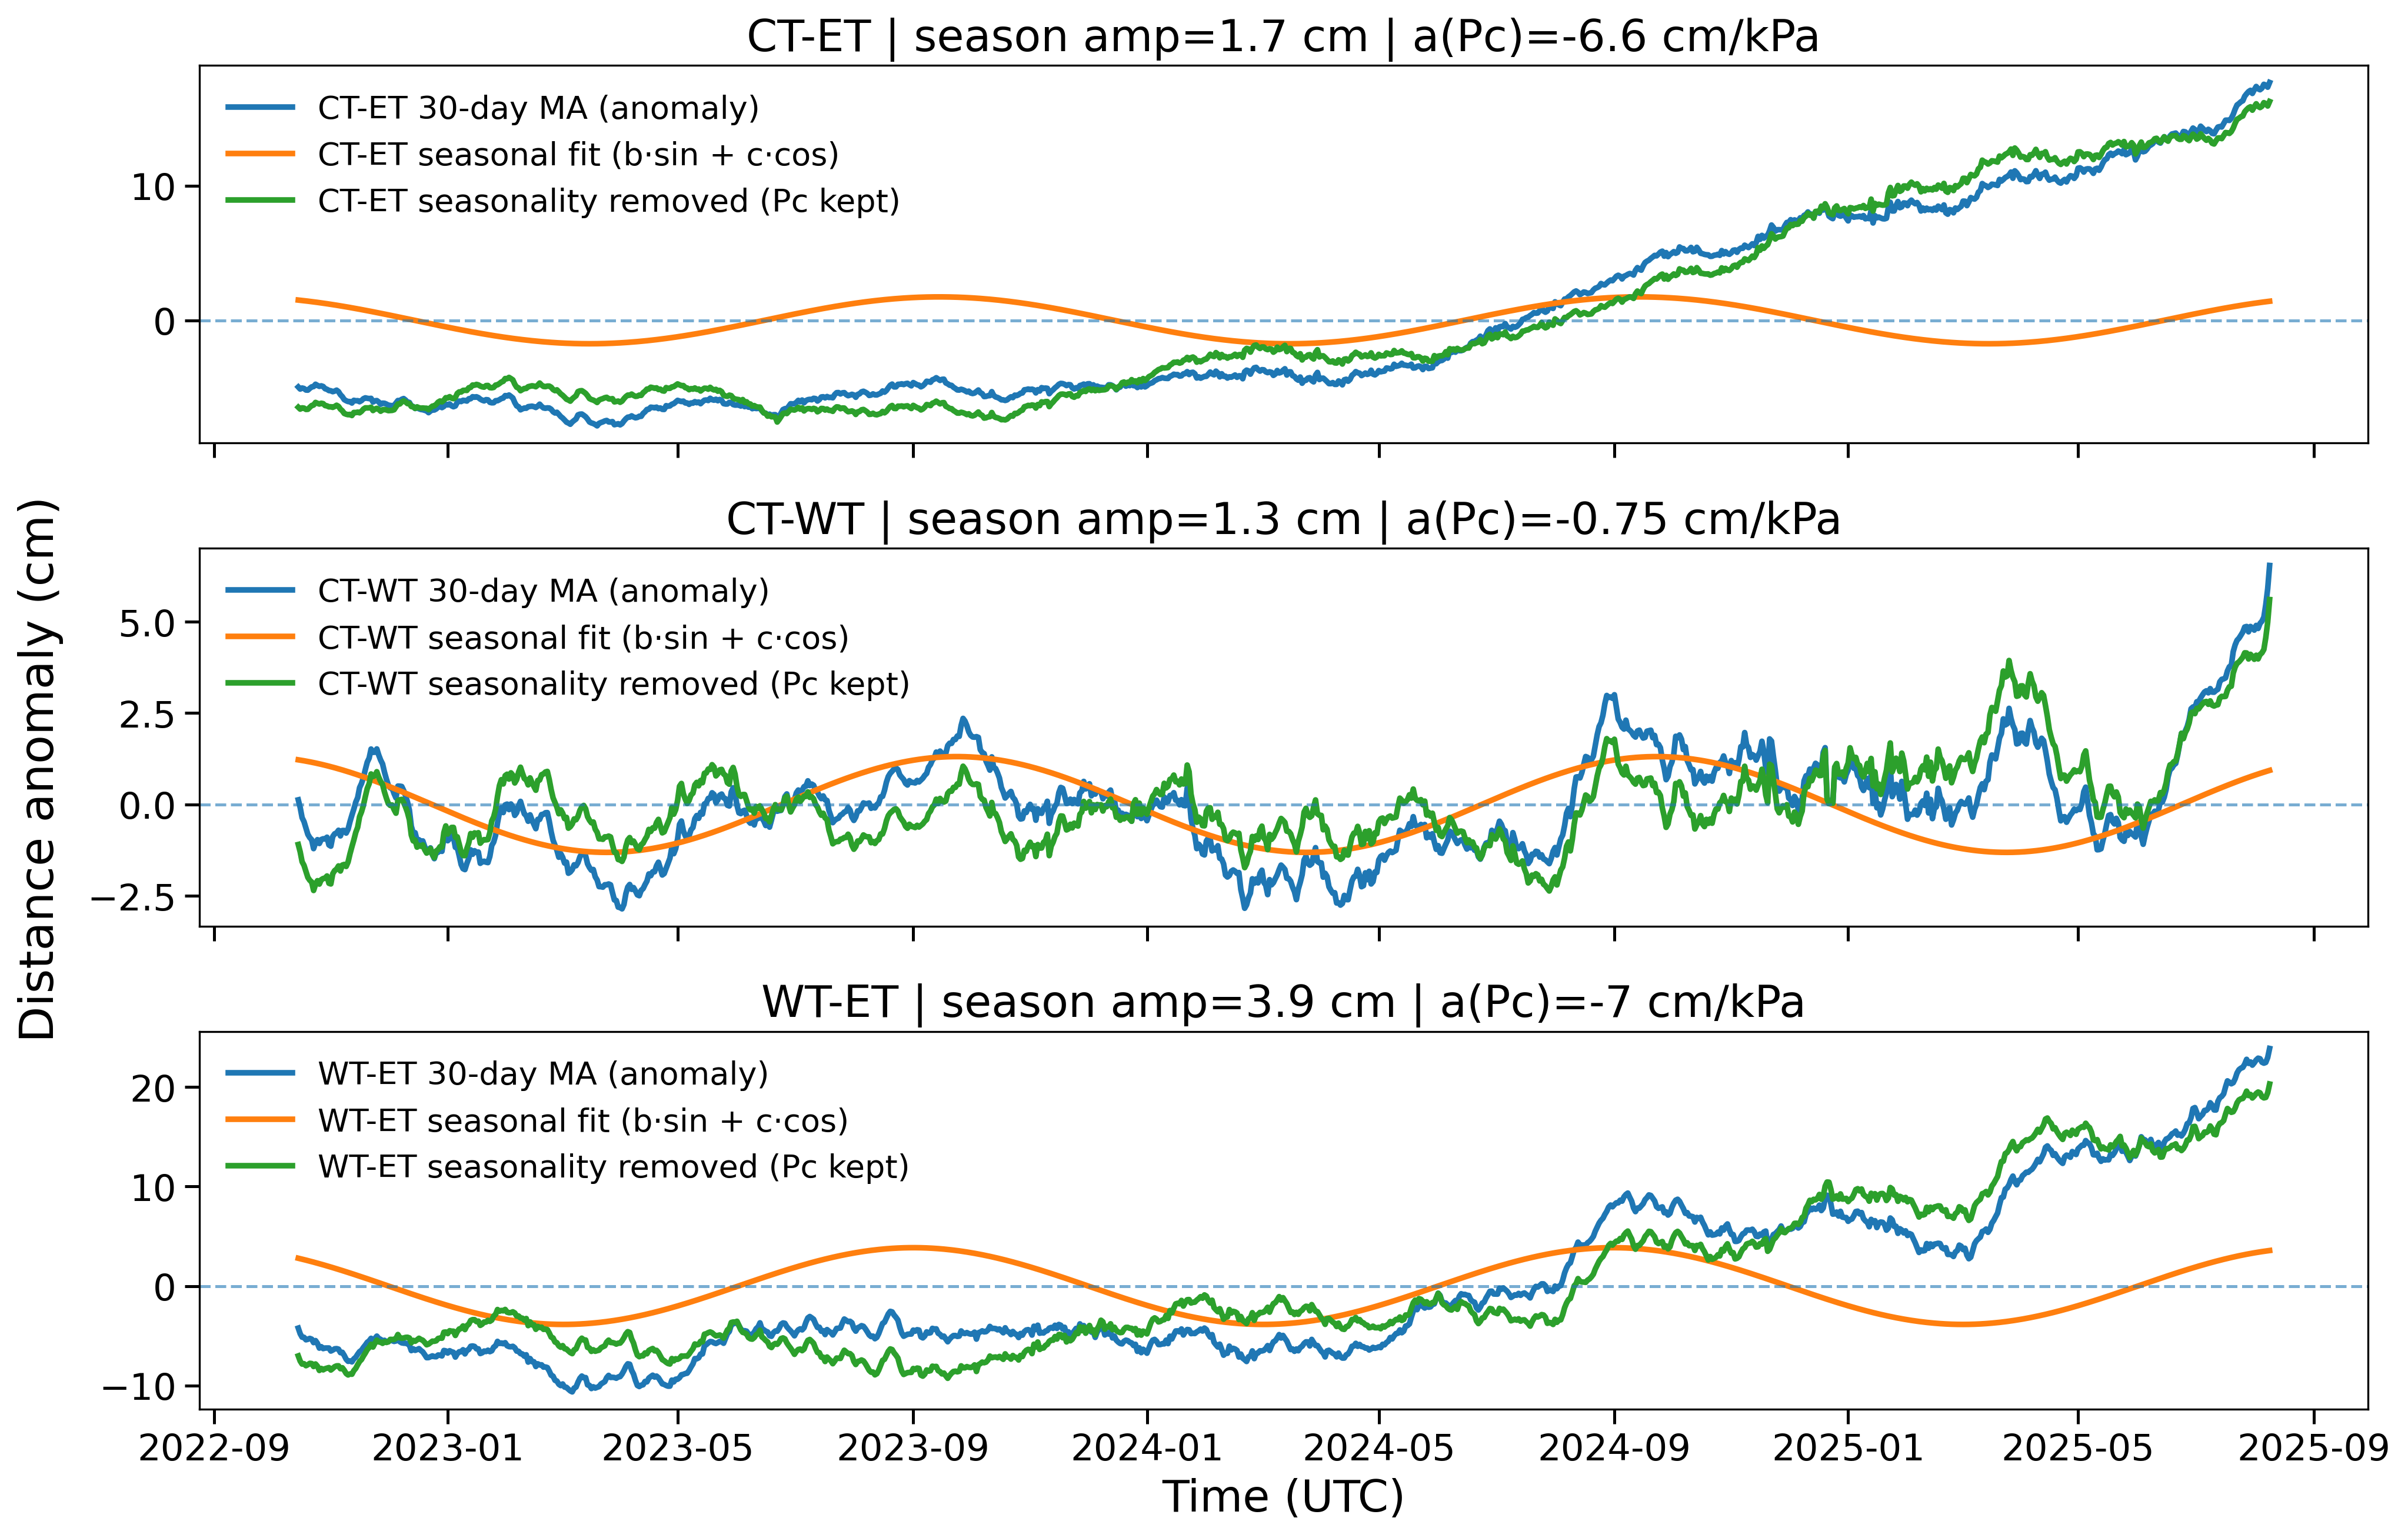

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CE_FILE = "CE_distance_longer.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pf_drifcor.csv"

DROP_DAYS = 30
MA_DAYS = 30

# ---- NEW: analysis end date ----
END_DATE = pd.Timestamp("2025-08-09", tz="UTC")  # inclusive

T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR  # rad/day

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

def _to_utc_datetime(s):
    return pd.to_datetime(s, utc=True, errors="coerce")

def pick_distance_column(df, name):
    candidates = [
        "Distance (cm)",
        "Moving Average (cm)",
        "distance_cm",
        "distance",
        "Distance",
        "Moving Average",
        "Baseline (cm)",
    ]
    for c in candidates:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            return c

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        raise ValueError(f"{name}: no numeric columns found to use as distance.")
    best, best_var = None, -np.inf
    for c in num_cols:
        v = float(np.nanvar(df[c].to_numpy()))
        if v > best_var:
            best_var = v
            best = c
    return best

def load_baseline_daily_ma30(path, name, drop_days=DROP_DAYS, ma_days=MA_DAYS):
    df = pd.read_csv(path)
    if "Record Time" not in df.columns:
        raise ValueError(f"{name}: expected a 'Record Time' column in {path}")
    df["Record Time"] = _to_utc_datetime(df["Record Time"])
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time").copy()

    dist_col = pick_distance_column(df, name)

    # Drop first DROP_DAYS from baseline's own start
    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=drop_days))].copy()

    daily = df.set_index("Record Time")[dist_col].resample("1D").mean()

    # 30-day moving average on daily series
    ma30 = daily.rolling(window=ma_days, min_periods=max(5, ma_days // 2)).mean()
    ma30.name = name
    return ma30, dist_col

def load_pc_daily(path):
    df = pd.read_csv(path)
    time_col = "Record Time" if "Record Time" in df.columns else ("time" if "time" in df.columns else None)
    if time_col is None:
        raise ValueError(f"PC file must contain 'Record Time' or 'time' column: {path}")
    df[time_col] = _to_utc_datetime(df[time_col])
    df = df.dropna(subset=[time_col]).sort_values(time_col).copy()

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError("PC file has no numeric columns to use as Pc.")
    pref = ["Pf", "Pc", "Pressure", "pressure", "Value", "value"]
    pc_col = None
    for p in pref:
        if p in df.columns and pd.api.types.is_numeric_dtype(df[p]):
            pc_col = p
            break
    if pc_col is None:
        pc_col = numeric_cols[0]

    pc = df.set_index(time_col)[pc_col].resample("1D").mean()
    pc.name = "Pc"
    return pc, pc_col, time_col

def fit_model_L_aPc_bsin_ccos_d(y_series, pc_series, t0_common):
    tmp = pd.concat([y_series, pc_series], axis=1).dropna()
    y = tmp.iloc[:, 0].to_numpy()
    pc = tmp.iloc[:, 1].to_numpy()

    t_days = (tmp.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([pc, sin_t, cos_t, np.ones_like(t_days)])
    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season = b * sin_t + c * cos_t
    deseason = y - season

    amp = float(np.sqrt(b * b + c * c))
    diag = {
        "a_Pc": float(a),
        "b_sin": float(b),
        "c_cos": float(c),
        "d_intercept": float(d),
        "season_amp_cm": amp,
        "season_ptp_cm": 2.0 * amp,
        "n_obs": int(len(y)),
    }

    idx = tmp.index
    season_s = pd.Series(season, index=idx, name=y_series.name + "_season")
    deseason_s = pd.Series(deseason, index=idx, name=y_series.name + "_deseason")
    return season_s, deseason_s, diag

# ---- NEW: robust endpoint extension using window means ----
def extension_cm(series, window_days=1):
    """
    Extension = mean(last window_days) - mean(first window_days), in the series' units.
    Assumes series is daily-ish indexed, with NaNs allowed.
    """
    s = series.dropna().sort_index()
    if len(s) == 0:
        return np.nan, (None, None), (None, None)

    start0 = s.index[0]
    end0 = s.index[-1]

    start_win = s.loc[start0 : (start0 + pd.Timedelta(days=window_days - 1))]
    end_win   = s.loc[(end0 - pd.Timedelta(days=window_days - 1)) : end0]

    start_mean = float(start_win.mean()) if len(start_win) else np.nan
    end_mean   = float(end_win.mean()) if len(end_win) else np.nan

    return (end_mean - start_mean), (start0, end0), (start_mean, end_mean)

# -----------------------------
# Run
# -----------------------------
baseline_series = {}
dist_cols = {}
for name, path in BASELINES:
    s, dist_col = load_baseline_daily_ma30(path, name)
    baseline_series[name] = s
    dist_cols[name] = dist_col

pc, pc_col, pc_time_col = load_pc_daily(PC_FILE)

# Align everything on common days, then truncate to END_DATE
df_all = pd.concat([baseline_series[n] for n, _ in BASELINES] + [pc], axis=1).dropna()
df_all = df_all.loc[:END_DATE].copy()   # <-- NEW

df = df_all[[n for n, _ in BASELINES]]
pc_aligned = df_all["Pc"]

if df.empty:
    raise RuntimeError(f"No overlapping baseline+Pc data up to END_DATE={END_DATE.date()} after dropna().")

t0_common = df.index[0]

print("=== Column picks ===")
for n in [x[0] for x in BASELINES]:
    print(f"{n}: distance column -> {dist_cols[n]}")
print(f"Pc: time column -> {pc_time_col} | pressure column -> {pc_col}")

print("\n=== Common overlap (TRUNCATED) ===")
print(f"start: {df.index[0].isoformat()}")
print(f"end  : {df.index[-1].isoformat()}")
print(f"days : {len(df)}")
print(f"END_DATE target: {END_DATE.isoformat()}")

season = pd.DataFrame(index=df.index)
deseason = pd.DataFrame(index=df.index)
diags = {}

for n in [x[0] for x in BASELINES]:
    s_seas, s_des, diag = fit_model_L_aPc_bsin_ccos_d(df[n], pc_aligned, t0_common)
    season[n] = s_seas.reindex(df.index)
    deseason[n] = s_des.reindex(df.index)
    diags[n] = diag

    print(
        f"\n==== {n} fit: L = a*Pc + b*sin + c*cos + d  (N={diag['n_obs']}) ====\n"
        f"a (Pc)       : {diag['a_Pc']:.8f}\n"
        f"b (sin)      : {diag['b_sin']:.8f}\n"
        f"c (cos)      : {diag['c_cos']:.8f}\n"
        f"d (intercept): {diag['d_intercept']:.8f}\n"
        f"season amp   : {diag['season_amp_cm']:.5f} cm  (ptp={diag['season_ptp_cm']:.5f} cm)\n"
    )

# ---- NEW: extension table (raw vs deseason) ----
label_map = {"CE": "CT-ET", "WC": "CT-WT", "WE": "WT-ET"}

rows = []
for n in [x[0] for x in BASELINES]:
    ext_raw, (tstart, tend), (m0_raw, m1_raw) = extension_cm(df[n], window_days=7)
    ext_des, (_, _), (m0_des, m1_des) = extension_cm(deseason[n], window_days=7)

    rows.append({
        "baseline": n,
        "label": label_map.get(n, n),
        "start": tstart,
        "end": tend,
        "raw_start_mean_cm": m0_raw,
        "raw_end_mean_cm": m1_raw,
        "raw_extension_cm": ext_raw,
        "deseason_start_mean_cm": m0_des,
        "deseason_end_mean_cm": m1_des,
        "deseason_extension_cm": ext_des,
    })

ext_df = pd.DataFrame(rows)

print("\n=== EXTENSION (cm): mean(last 7 days) - mean(first 7 days), up to 2025-05-01 ===")
with pd.option_context("display.max_columns", 999, "display.width", 160):
    print(ext_df[[
        "label", "start", "end",
        "raw_extension_cm", "deseason_extension_cm",
        "raw_start_mean_cm", "raw_end_mean_cm",
        "deseason_start_mean_cm", "deseason_end_mean_cm"
    ]].to_string(index=False))

# ---- publication-style defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})

# Plot anomalies for readability (remove mean of MA series per baseline)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), dpi=300, sharex=True)

for ax, n in zip(axes, [x[0] for x in BASELINES]):
    nlab = label_map.get(n, n)
    y0 = float(df[n].mean())

    ax.plot(df.index, df[n] - y0, lw=2.3, label=f"{nlab} 30-day MA (anomaly)")
    ax.plot(df.index, season[n], lw=2.3, label=f"{nlab} seasonal fit (b·sin + c·cos)")
    ax.plot(df.index, deseason[n] - y0, lw=2.3, label=f"{nlab} seasonality removed (Pc kept)")

    ax.set_title(
        f"{nlab} | season amp={diags[n]['season_amp_cm']:.1f} cm"
        f" | a(Pc)={diags[n]['a_Pc']:.2g} cm/kPa"
    )
    ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
    ax.tick_params(axis="both", which="major", length=6, width=1.2)
    ax.legend(frameon=False, loc="upper left")

axes[-1].set_xlabel("Time (UTC)")
fig.supylabel("Distance anomaly (cm)")
fig.tight_layout()
plt.show()


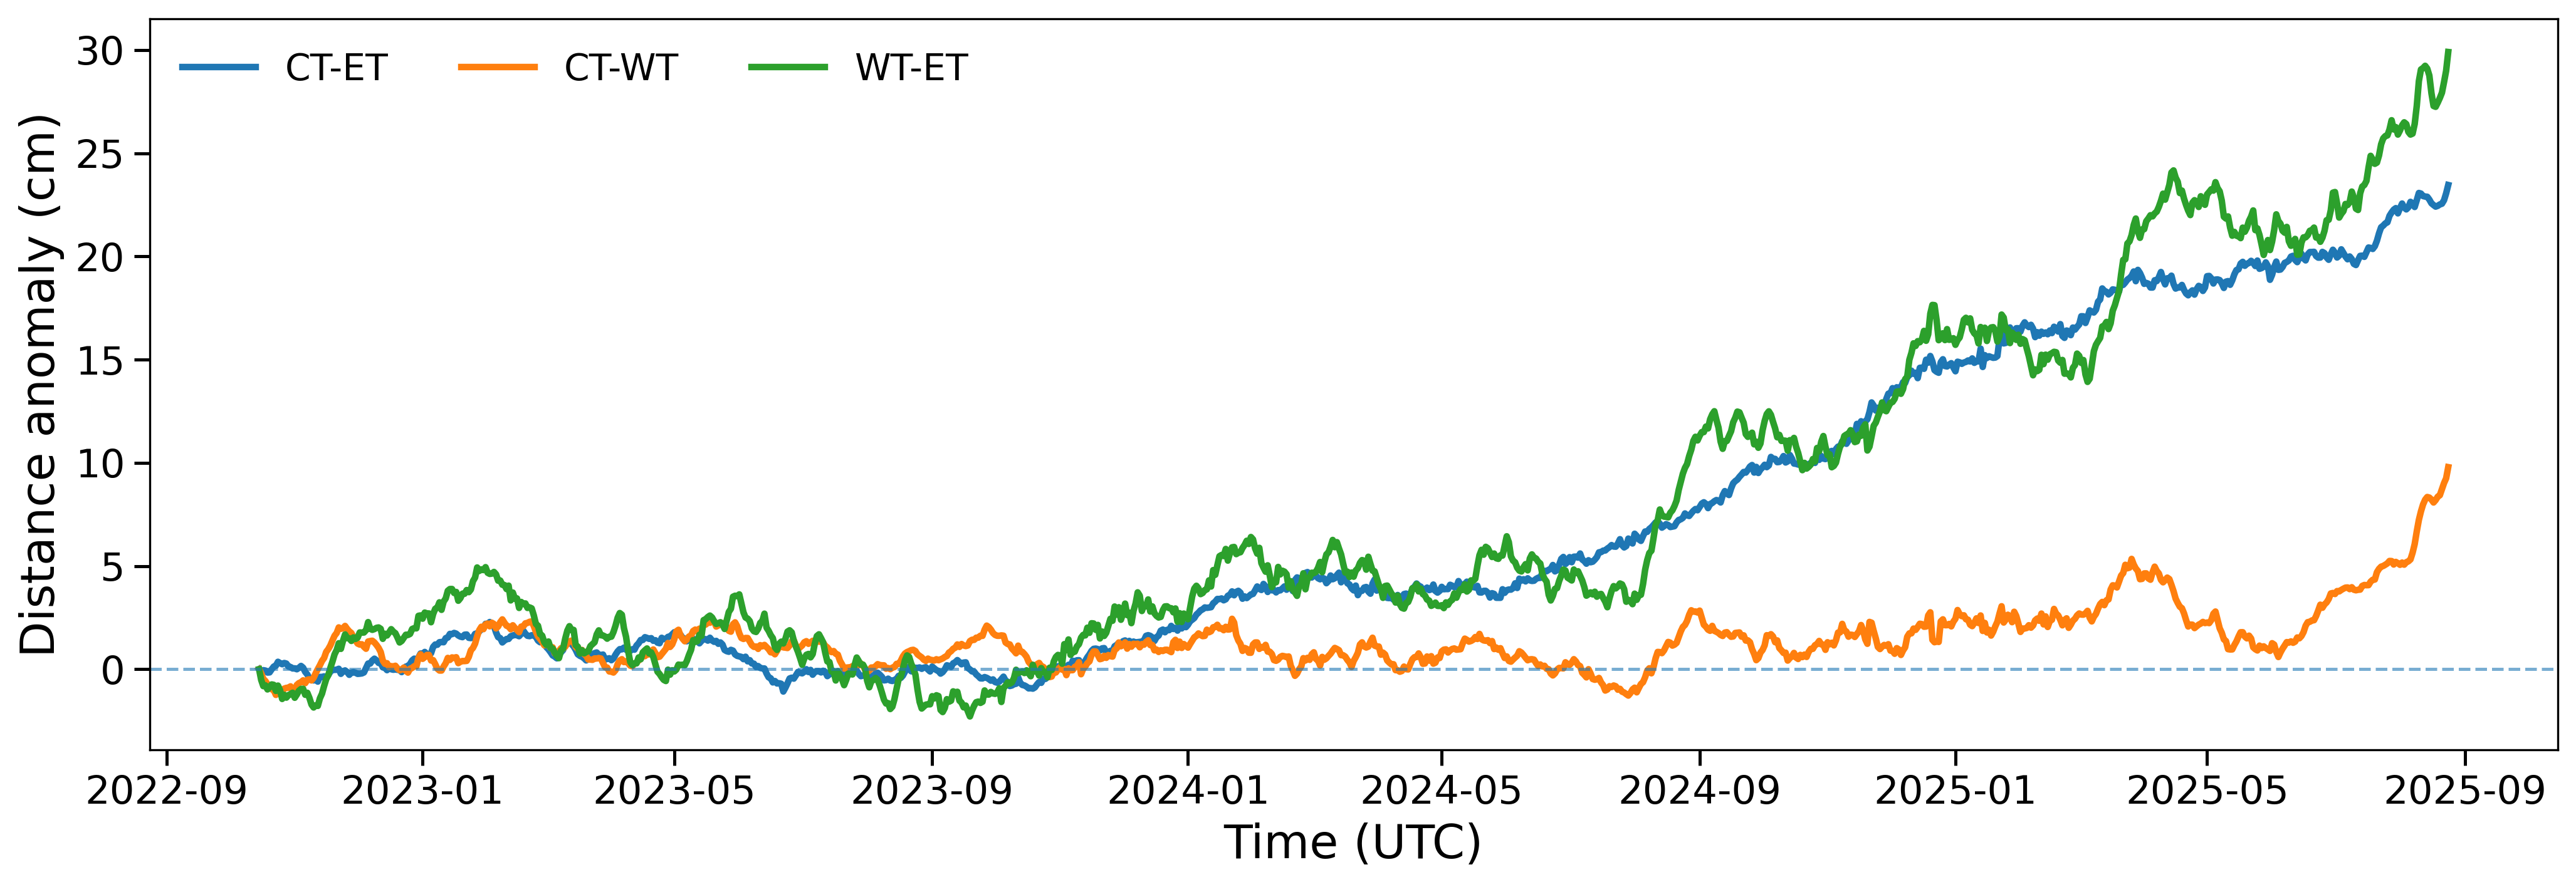

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

path = "baselines_fit_outputs.csv"
df = pd.read_csv(path)

# identify time column
time_col = None
for c in ["Record Time", "RecordTime", "time", "Time", "date", "Date", "Unnamed: 0"]:
    if c in df.columns:
        time_col = c
        break
if time_col is None:
    time_col = df.columns[0]

t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.assign(Time=t).dropna(subset=["Time"]).set_index("Time").sort_index()

cols = ["CE_deseason_PcKept", "WC_deseason_PcKept", "WE_deseason_PcKept"]
plot_df = df[cols].dropna()

# anomaly from the first common timestamp (each starts at 0)
anom = plot_df.copy()
for c in cols:
    anom[c] = anom[c] - float(anom[c].iloc[0])

import matplotlib.pyplot as plt

# ---- publication-style defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})

# Map your baseline names (after the replace) to desired legend labels
label_map = {
    "CE": "CT-ET",
    "WC": "CT-WT",
    "WE": "WT-ET",
    # if your cols are named differently, add keys here
}

fig, ax = plt.subplots(figsize=(14, 5), dpi=300)

for c in cols:
    base = c.replace("_deseason_PcKept", "")
    ax.plot(anom.index, anom[c], linewidth=2.5, label=label_map.get(base, base))

ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Distance anomaly (cm)")
#ax.set_title("Seasonality-removed baselines")

ax.tick_params(axis="both", which="major", length=6, width=1.2)
ax.legend(frameon=False, ncol=3, loc="upper left")
fig.tight_layout()
plt.show()


/tmp/ipykernel_939368/1804197653.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


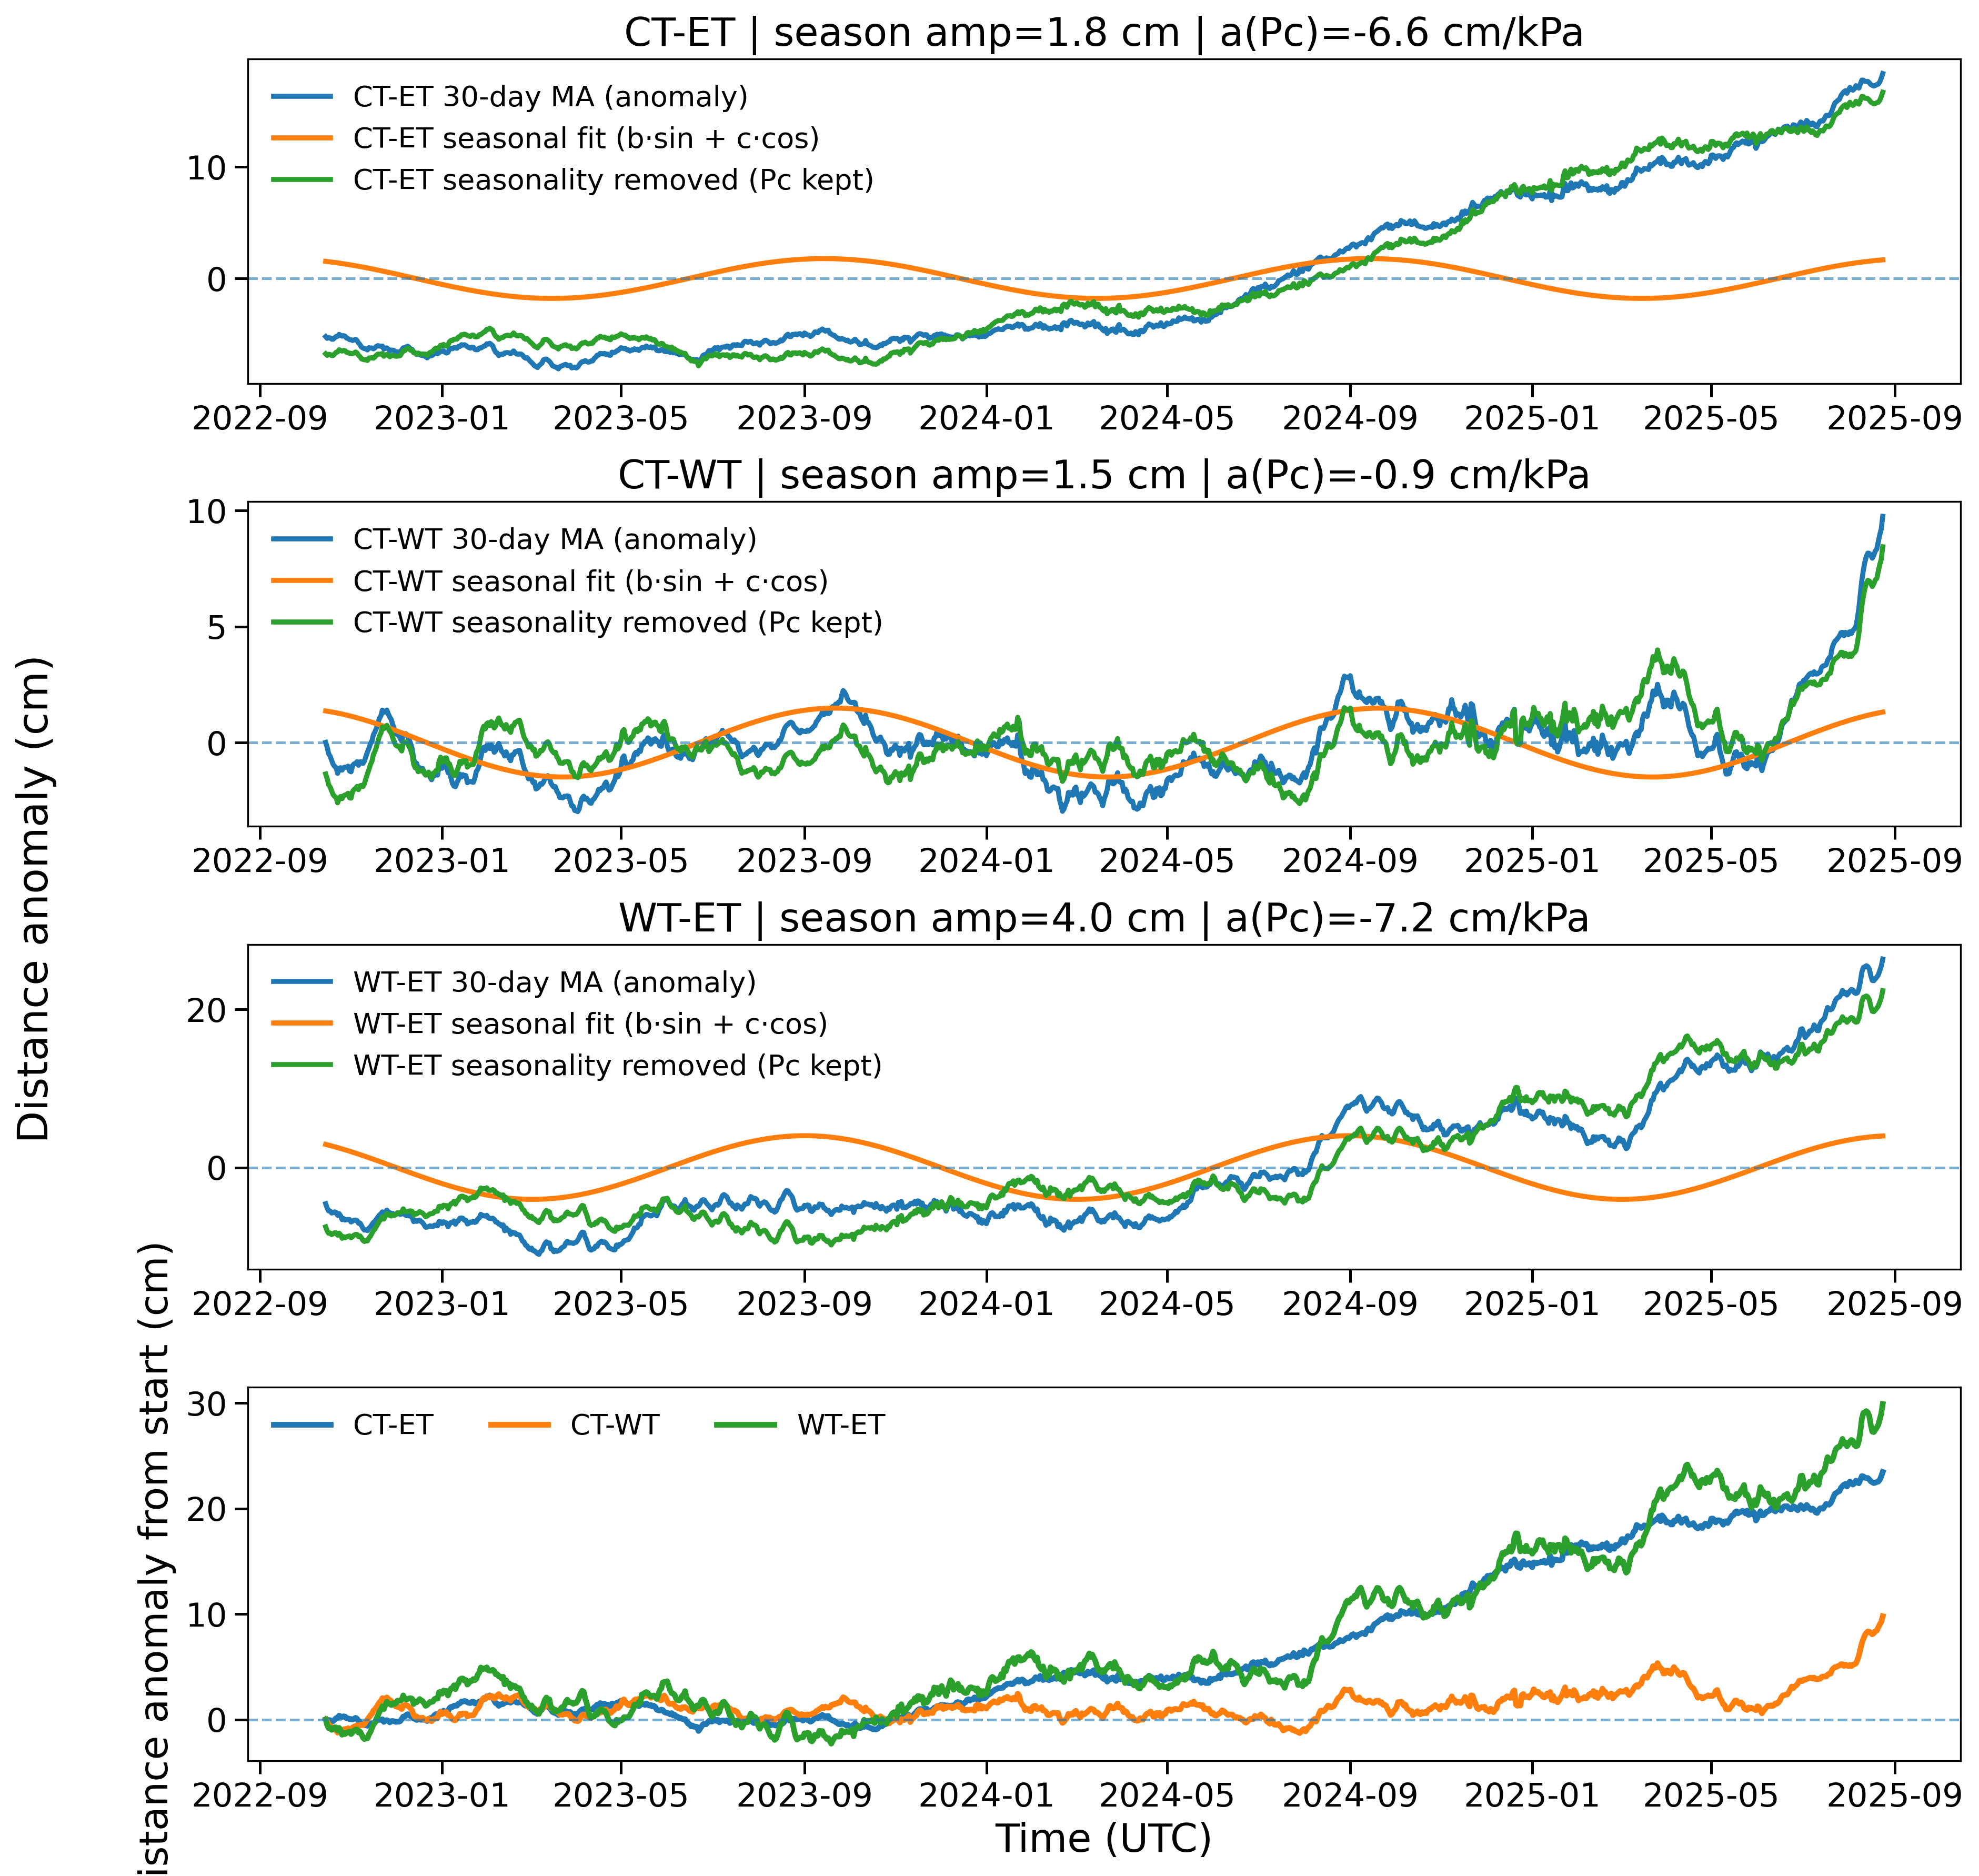

In [38]:
import matplotlib.pyplot as plt

# ---- publication-style defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})

label_map = {"CE": "CT-ET", "WC": "CT-WT", "WE": "WT-ET"}
names = [n for n, _ in BASELINES]

def _get_series(n, kind):
    """
    kind in {"ma30","season","deseason"}
    Tries multiple places/names so it works pre- and post-CSV.
    Returns a pandas Series with a DatetimeIndex.
    """
    # 1) Prefer in-memory objects if they exist
    if kind == "ma30":
        if "baseline_series" in globals() and n in baseline_series:
            return baseline_series[n]
        if "df" in globals() and n in getattr(df, "columns", []):
            return df[n]
    if kind == "season":
        if "season" in globals() and n in getattr(season, "columns", []):
            return season[n]
    if kind == "deseason":
        if "deseason" in globals() and n in getattr(deseason, "columns", []):
            return deseason[n]

    # 2) Otherwise, assume you're in the CSV-loaded dataframe stage
    if "df" in globals():
        candidates = []
        if kind == "ma30":
            candidates = [f"{n}_MA30", n]
        elif kind == "season":
            candidates = [f"{n}_season_fit", f"{n}_season"]
        elif kind == "deseason":
            candidates = [f"{n}_deseason_PcKept", f"{n}_deseason", n]

        for c in candidates:
            if c in df.columns:
                return df[c]

    raise KeyError(f"Could not find series for {n} ({kind}).")

# ---- build a common time index from deseason series overlap ----
idx = None
for n in names:
    s = _get_series(n, "deseason").dropna()
    idx = s.index if idx is None else idx.intersection(s.index)
idx = idx.sort_values()

# ------------------------------------------------------------
# Combined figure: 3 per-baseline panels FIRST, combined LAST
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 14), dpi=300)
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1.15], hspace=0.35)

# ---- Bottom (actually last panel): combined deseason anomaly-from-start (your last figure) ----
ax_last = fig.add_subplot(gs[3, 0])

# ---- First 3 panels: per-baseline MA anomaly + season + deseason ----
axes = [fig.add_subplot(gs[i, 0], sharex=ax_last) for i in [0, 1, 2]]

for ax, n in zip(axes, names):
    nlab = label_map.get(n, n)

    y = _get_series(n, "ma30").reindex(idx)
    s_season = _get_series(n, "season").reindex(idx)
    s_des = _get_series(n, "deseason").reindex(idx)

    y0 = float(y.mean())

    ax.plot(idx, y - y0, lw=2.3, label=f"{nlab} 30-day MA (anomaly)")
    ax.plot(idx, s_season, lw=2.3, label=f"{nlab} seasonal fit (b·sin + c·cos)")
    ax.plot(idx, s_des - y0, lw=2.3, label=f"{nlab} seasonality removed (Pc kept)")

    # Title: use diags if available; otherwise just label
    if "diags" in globals() and n in diags:
        ax.set_title(
            f"{nlab} | season amp={diags[n]['season_amp_cm']:.1f} cm"
            f" | a(Pc)={diags[n]['a_Pc']:.2g} cm/kPa"
        )
    else:
        ax.set_title(nlab)

    ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
    ax.tick_params(axis="both", which="major", length=6, width=1.2)
    ax.legend(frameon=False, loc="upper left")

# ---- Combined (last) panel: anomaly from start, each starts at 0 ----
for n in names:
    nlab = label_map.get(n, n)
    s_des = _get_series(n, "deseason").reindex(idx)

    s0 = float(s_des.dropna().iloc[0])
    ax_last.plot(idx, s_des - s0, lw=2.6, label=nlab)

ax_last.axhline(0, lw=1.2, ls="--", alpha=0.6)
ax_last.set_xlabel("Time (UTC)")
ax_last.set_ylabel("Distance anomaly from start (cm)")
ax_last.tick_params(axis="both", which="major", length=6, width=1.2)
ax_last.legend(frameon=False, ncol=3, loc="upper left")
# ax_last.set_title("Seasonality removed (Pc kept): anomaly from start")

fig.supylabel("Distance anomaly (cm)")
fig.tight_layout()
plt.show()


/tmp/ipykernel_939368/645545895.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


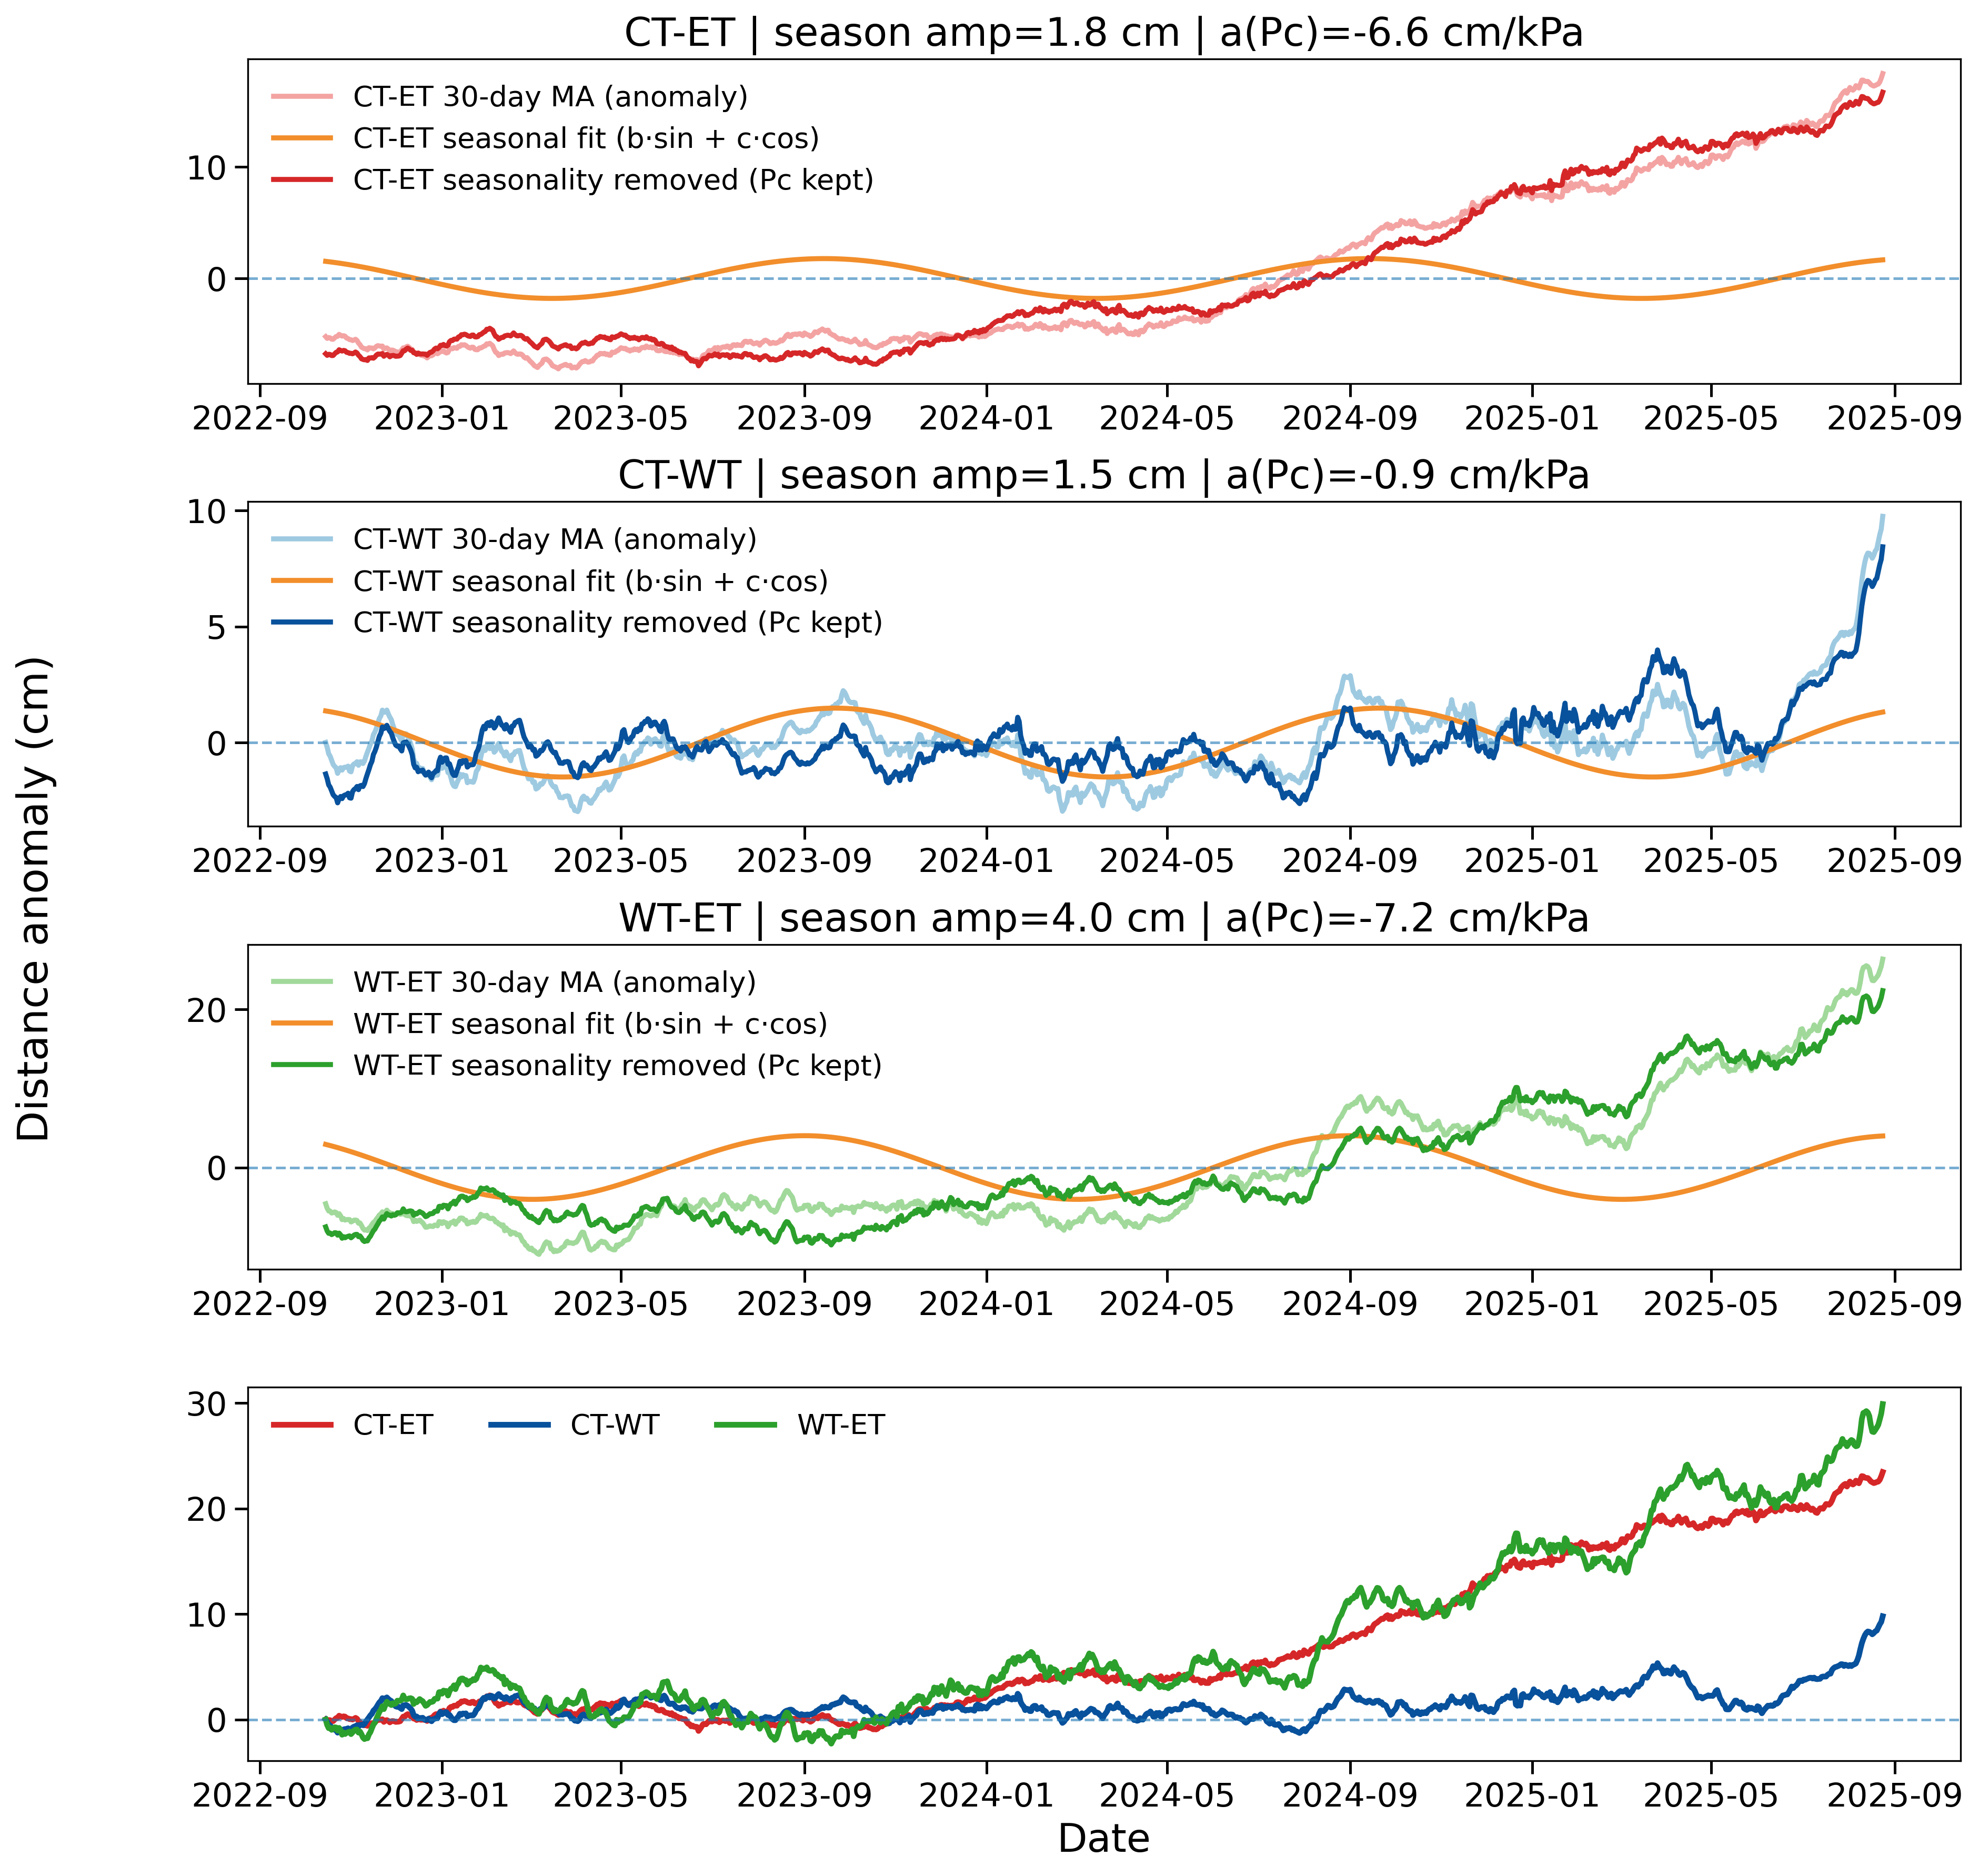

In [45]:
import matplotlib.pyplot as plt

# ---- publication-style defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})

label_map = {"CE": "CT-ET", "WC": "CT-WT", "WE": "WT-ET"}
names = [n for n, _ in BASELINES]

# ---- Color palette (explicit, per your request) ----
ORANGE = "#F28E2B"     # seasonality curves (all panels)
LIGHT_RED = "#F4A3A3"
MAROON = "#D62728"
LIGHT_BLUE = "#9ECAE1"
DARK_BLUE = "#08519C"
LIGHT_GREEN = "#A1D99B"
DARK_GREEN = "#2CA02C"

# Per-panel colors for MA anomaly and deseason (Pc kept)
panel_colors = {
    "CE": {"ma": LIGHT_RED,   "des": MAROON},
    "WC": {"ma": LIGHT_BLUE,  "des": DARK_BLUE},
    "WE": {"ma": LIGHT_GREEN, "des": DARK_GREEN},
}

# Combined panel colors (deseason anomaly-from-start)
combined_colors = {"CE": MAROON, "WC": DARK_BLUE, "WE": DARK_GREEN}

def _get_series(n, kind):
    """
    kind in {"ma30","season","deseason"}
    Tries multiple places/names so it works pre- and post-CSV.
    Returns a pandas Series with a DatetimeIndex.
    """
    # 1) Prefer in-memory objects if they exist
    if kind == "ma30":
        if "baseline_series" in globals() and n in baseline_series:
            return baseline_series[n]
        if "df" in globals() and n in getattr(df, "columns", []):
            return df[n]
    if kind == "season":
        if "season" in globals() and n in getattr(season, "columns", []):
            return season[n]
    if kind == "deseason":
        if "deseason" in globals() and n in getattr(deseason, "columns", []):
            return deseason[n]

    # 2) Otherwise, assume you're in the CSV-loaded dataframe stage
    if "df" in globals():
        if kind == "ma30":
            candidates = [f"{n}_MA30", n]
        elif kind == "season":
            candidates = [f"{n}_season_fit", f"{n}_season"]
        elif kind == "deseason":
            candidates = [f"{n}_deseason_PcKept", f"{n}_deseason", n]
        else:
            candidates = []

        for c in candidates:
            if c in df.columns:
                return df[c]

    raise KeyError(f"Could not find series for {n} ({kind}).")

# ---- build a common time index from deseason overlap ----
idx = None
for n in names:
    s = _get_series(n, "deseason").dropna()
    idx = s.index if idx is None else idx.intersection(s.index)
idx = idx.sort_values()

# ------------------------------------------------------------
# Combined figure: 3 per-baseline panels FIRST, combined LAST
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 14), dpi=300)
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1.15], hspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0], sharex=ax1)  # combined panel (last)

axes = [ax1, ax2, ax3]

# ---- Panels 1-3: per-baseline ----
for ax, n in zip(axes, names):
    nlab = label_map.get(n, n)

    y = _get_series(n, "ma30").reindex(idx)
    s_season = _get_series(n, "season").reindex(idx)
    s_des = _get_series(n, "deseason").reindex(idx)

    y0 = float(y.mean())

    ax.plot(idx, y - y0, lw=2.3, color=panel_colors[n]["ma"],
            label=f"{nlab} 30-day MA (anomaly)")
    ax.plot(idx, s_season, lw=2.3, color=ORANGE,
            label=f"{nlab} seasonal fit (b·sin + c·cos)")
    ax.plot(idx, s_des - y0, lw=2.3, color=panel_colors[n]["des"],
            label=f"{nlab} seasonality removed (Pc kept)")

    # Title (use diags if available)
    if "diags" in globals() and n in diags:
        ax.set_title(
            f"{nlab} | season amp={diags[n]['season_amp_cm']:.1f} cm"
            f" | a(Pc)={diags[n]['a_Pc']:.2g} cm/kPa"
        )
    else:
        ax.set_title(nlab)

    ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
    ax.tick_params(axis="both", which="major", length=6, width=1.2)
    ax.legend(frameon=False, loc="upper left")

# ---- Panel 4: combined deseason anomaly-from-start ----
for n in names:
    nlab = label_map.get(n, n)
    s_des = _get_series(n, "deseason").reindex(idx)

    s0 = float(s_des.dropna().iloc[0])  # start at 0 for each
    ax4.plot(idx, s_des - s0, lw=2.6, color=combined_colors[n], label=nlab)
    ax4.plot(idx, s_des - s0, lw=2.6, color=combined_colors[n], label=nlab)

ax4.axhline(0, lw=1.2, ls="--", alpha=0.6)
ax4.set_xlabel("Date")
ax4.tick_params(axis="both", which="major", length=6, width=1.2)
ax4.legend(frameon=False, ncol=3, loc="upper left")

fig.supylabel("Distance anomaly (cm)")
fig.tight_layout()
plt.show()


2022-10-15 00:00:00+00:00    326016.460978
2022-10-16 00:00:00+00:00    326015.941779
2022-10-17 00:00:00+00:00    326015.644584
2022-10-18 00:00:00+00:00    326015.682777
2022-10-19 00:00:00+00:00    326015.484777
                                 ...      
2025-08-20 00:00:00+00:00    326044.134132
2025-08-21 00:00:00+00:00    326044.390332
2025-08-22 00:00:00+00:00    326044.905409
2025-08-23 00:00:00+00:00    326045.455767
2025-08-24 00:00:00+00:00    326046.362225
Freq: D, Name: WE, Length: 1045, dtype: float64

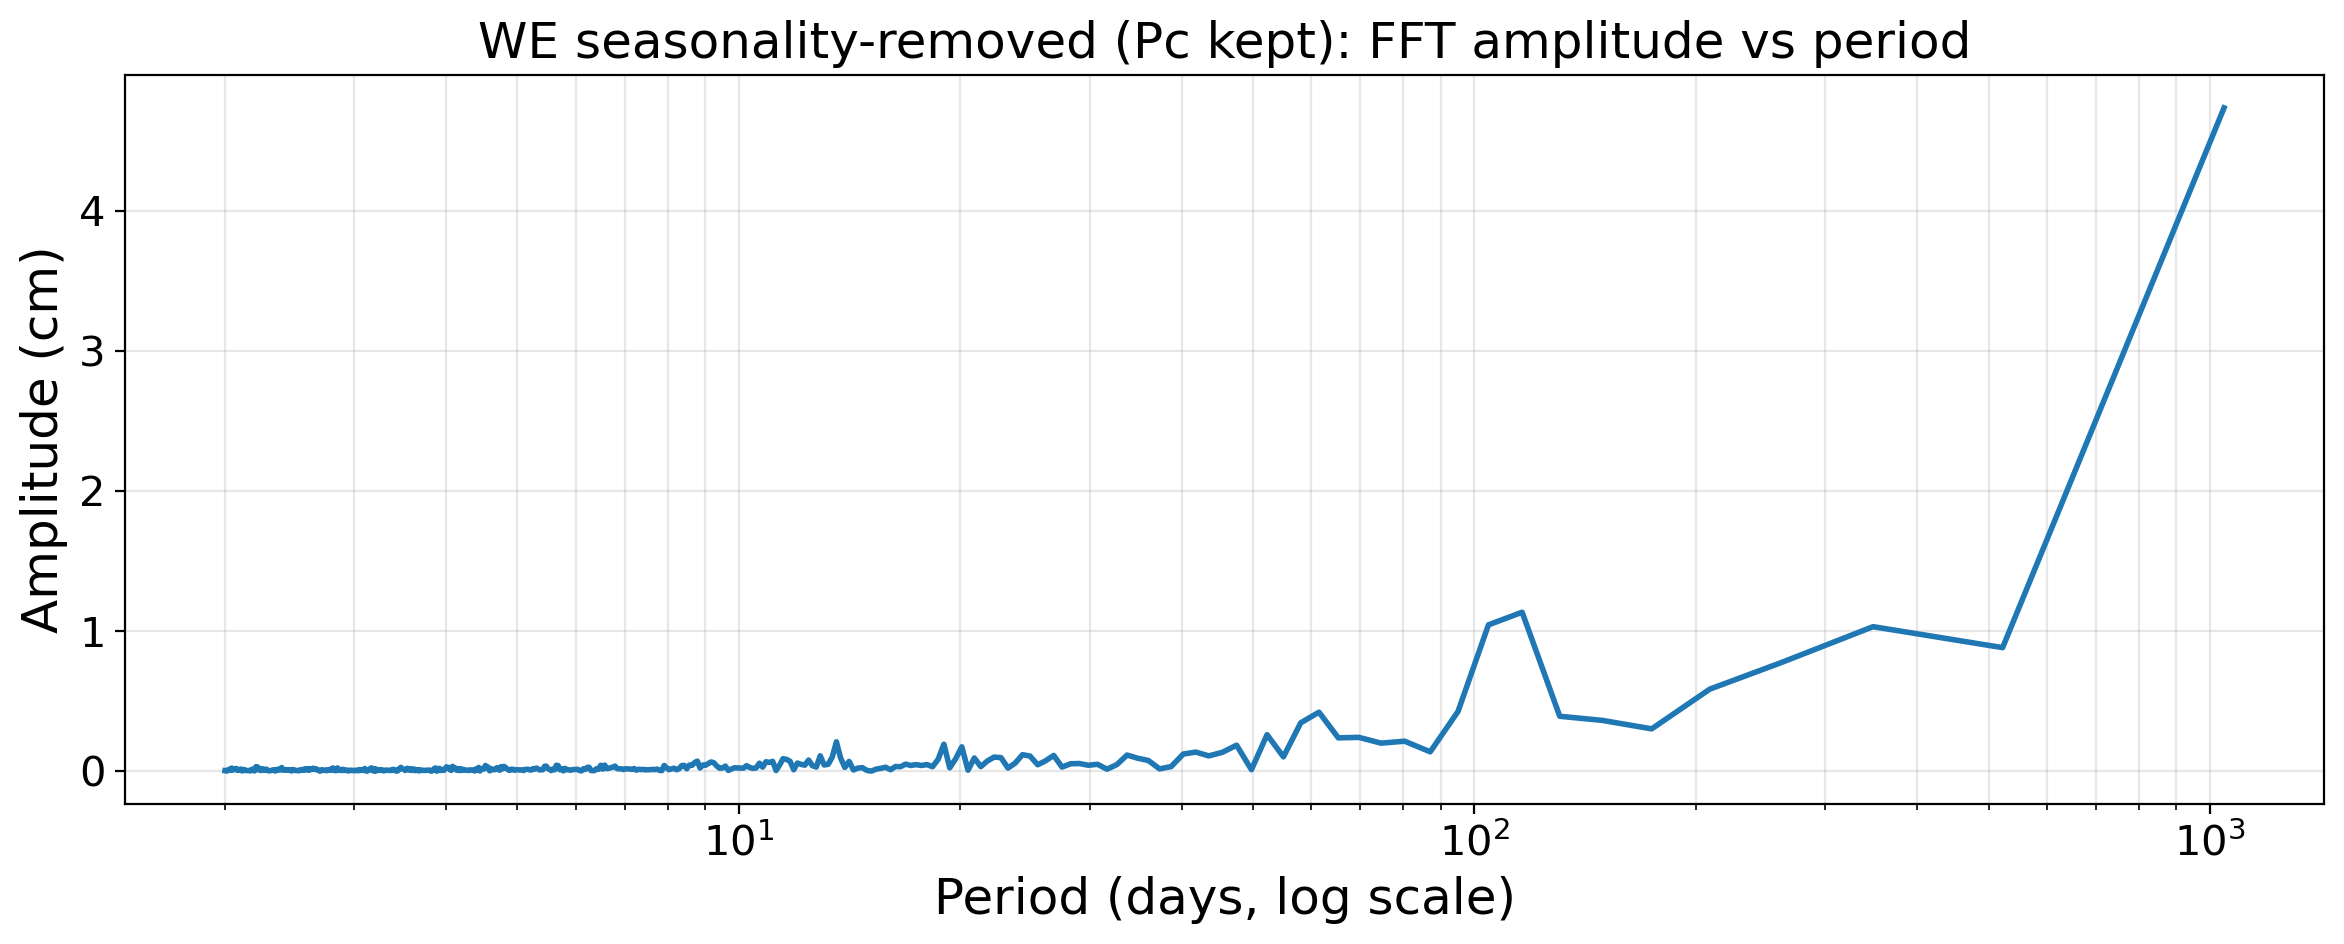

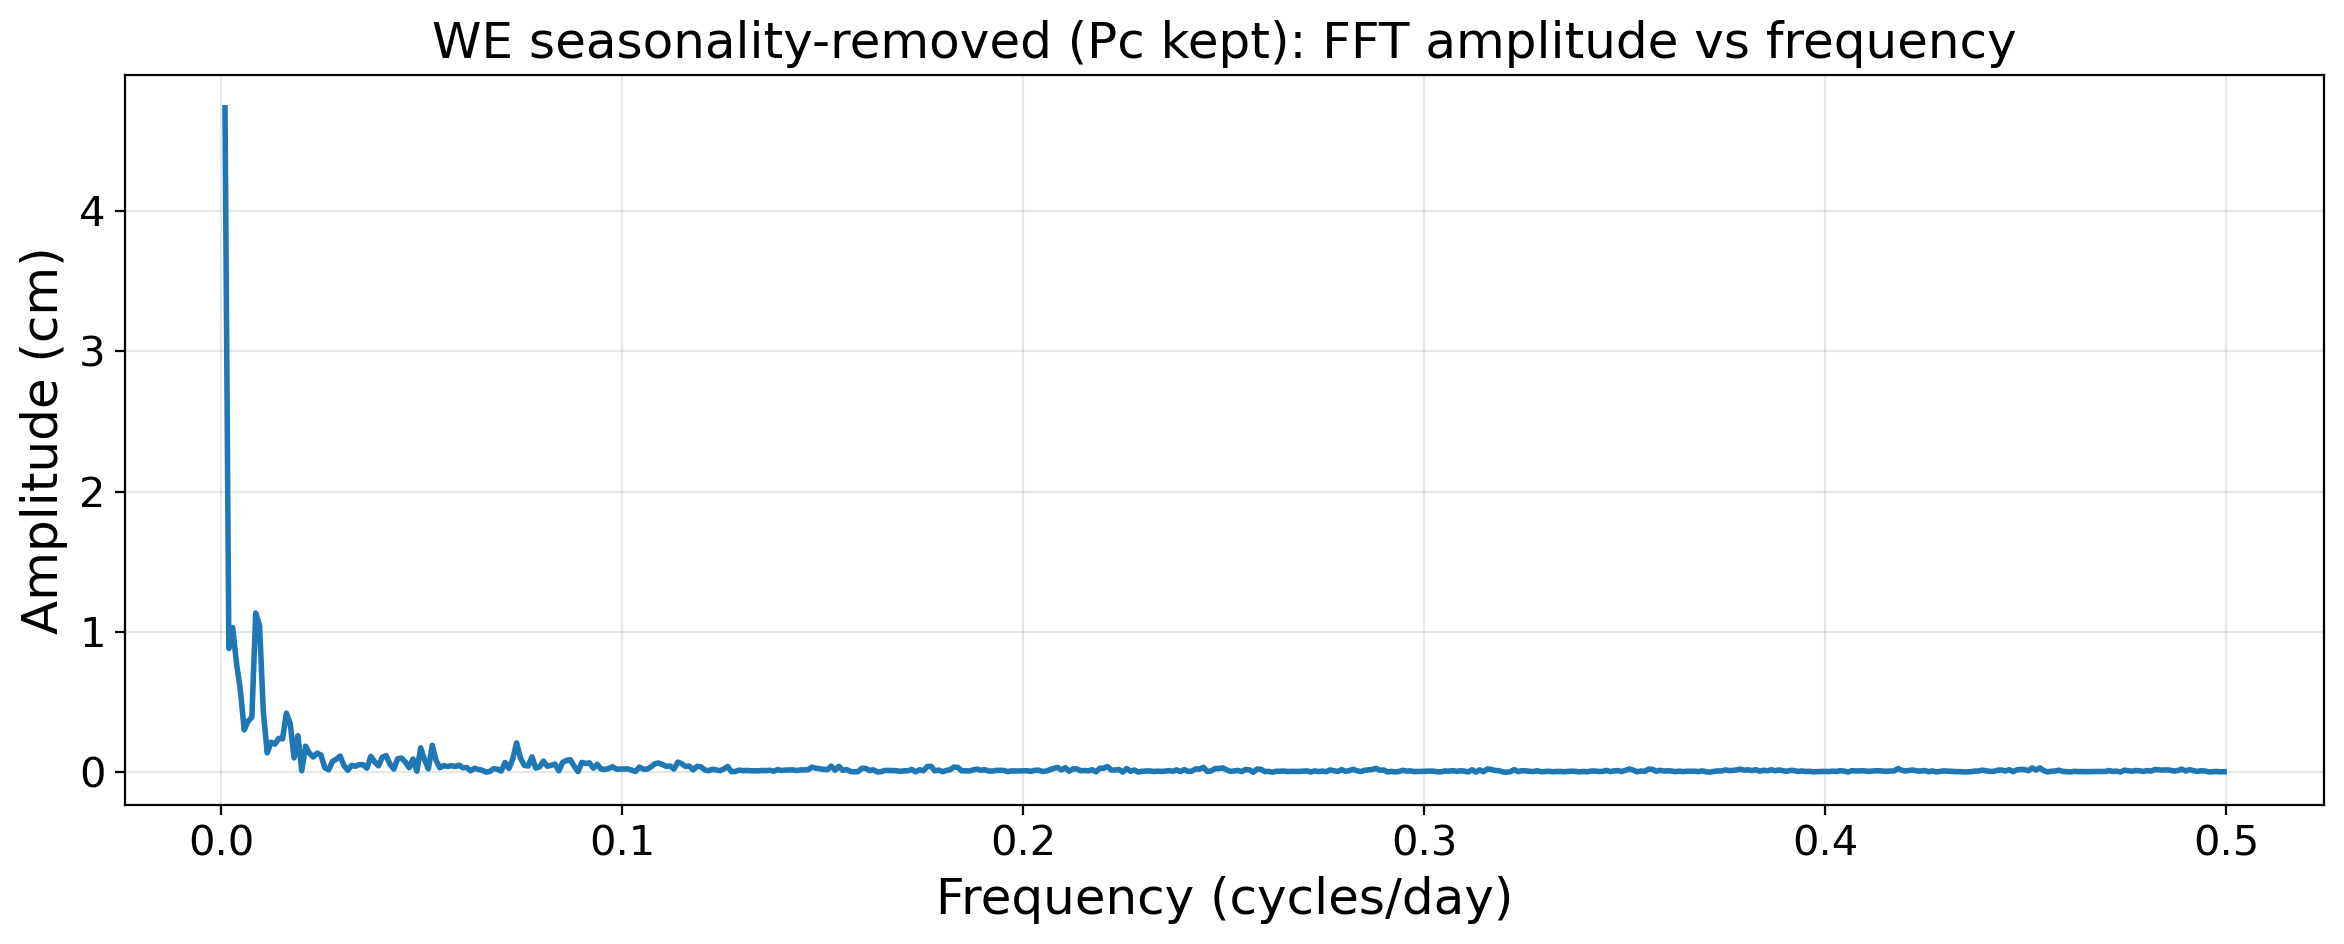

Top 10 spectral peaks (WE, detrended, daily):
  period =  1045.00 days | freq =   0.000957 cyc/day | amp = 4.7336 cm
  period =   116.11 days | freq =   0.008612 cyc/day | amp = 1.1346 cm
  period =   104.50 days | freq =   0.009569 cyc/day | amp = 1.0447 cm
  period =   348.33 days | freq =   0.002871 cyc/day | amp = 1.0316 cm
  period =   522.50 days | freq =   0.001914 cyc/day | amp = 0.8821 cm
  period =   261.25 days | freq =   0.003828 cyc/day | amp = 0.7752 cm
  period =   209.00 days | freq =   0.004785 cyc/day | amp = 0.5863 cm
  period =    95.00 days | freq =   0.010526 cyc/day | amp = 0.4269 cm
  period =    61.47 days | freq =   0.016268 cyc/day | amp = 0.4213 cm
  period =   130.62 days | freq =   0.007656 cyc/day | amp = 0.3924 cm


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Fourier transform of seasonality-removed WE signal (Pc kept)
# Assumes you already computed: deseason["WE"] (a Series) OR
# you have a CSV-loaded df with column "WE_deseason_PcKept".
# ============================================================

# ---- 1) Get the WE seasonality-removed series ----
if "deseason" in globals() and hasattr(deseason, "columns") and "WE" in deseason.columns:
    we = deseason["WE"].copy()
elif "df" in globals() and "WE_deseason_PcKept" in df.columns:
    we = df["WE_deseason_PcKept"].copy()
else:
    raise KeyError("Couldn't find WE seasonality-removed series. Need deseason['WE'] or df['WE_deseason_PcKept'].")

# Ensure time index is datetime (UTC) if needed
if not isinstance(we.index, pd.DatetimeIndex):
    # try to coerce index
    we.index = pd.to_datetime(we.index, utc=True, errors="coerce")
we = we.dropna()
we = we.sort_index()

# ---- 2) Resample to uniform daily sampling (FFT needs evenly spaced samples) ----
# Daily mean then interpolate any gaps
we_daily = we.resample("1D").mean()
we_daily = we_daily.interpolate("time").dropna()

# ---- 3) Remove mean + (optional) linear trend before FFT ----
t = np.arange(len(we_daily), dtype=float)
y = we_daily.to_numpy().astype(float)

# remove linear trend
p = np.polyfit(t, y, 1)
y_detr = y - (p[0]*t + p[1])

# also remove mean (safe)
y_detr = y_detr - np.mean(y_detr)

# ---- 4) FFT (one-sided) ----
dt_days = 1.0  # daily sampling
N = len(y_detr)

freq_cpd = np.fft.rfftfreq(N, d=dt_days)     # cycles per day
fft_vals = np.fft.rfft(y_detr)

# amplitude spectrum (scaled)
amp = (2.0 / N) * np.abs(fft_vals)
# (DC term shouldn't be doubled, but we removed mean so it's ~0 anyway)

# Avoid f=0 for period plot
mask = freq_cpd > 0
freq_cpd_nz = freq_cpd[mask]
amp_nz = amp[mask]
period_days = 1.0 / freq_cpd_nz

# ---- 5) Plot: amplitude vs period (days) ----
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(period_days, amp_nz, lw=2)
plt.xscale("log")
plt.xlabel("Period (days, log scale)")
plt.ylabel("Amplitude (cm)")
plt.title("WE seasonality-removed (Pc kept): FFT amplitude vs period")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 6) Optional: plot amplitude vs frequency (cycles/day) ----
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(freq_cpd_nz, amp_nz, lw=2)
plt.xlabel("Frequency (cycles/day)")
plt.ylabel("Amplitude (cm)")
plt.title("WE seasonality-removed (Pc kept): FFT amplitude vs frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 7) Print top peaks (by amplitude) ----
k = 10
top = np.argsort(amp_nz)[-k:][::-1]
print(f"Top {k} spectral peaks (WE, detrended, daily):")
for i in top:
    f = freq_cpd_nz[i]
    print(f"  period = {1/f:8.2f} days | freq = {f:10.6f} cyc/day | amp = {amp_nz[i]:.4f} cm")


116.11-day fitted peak amplitude: 1.6080 cm (FFT reported ~1.1346 cm)


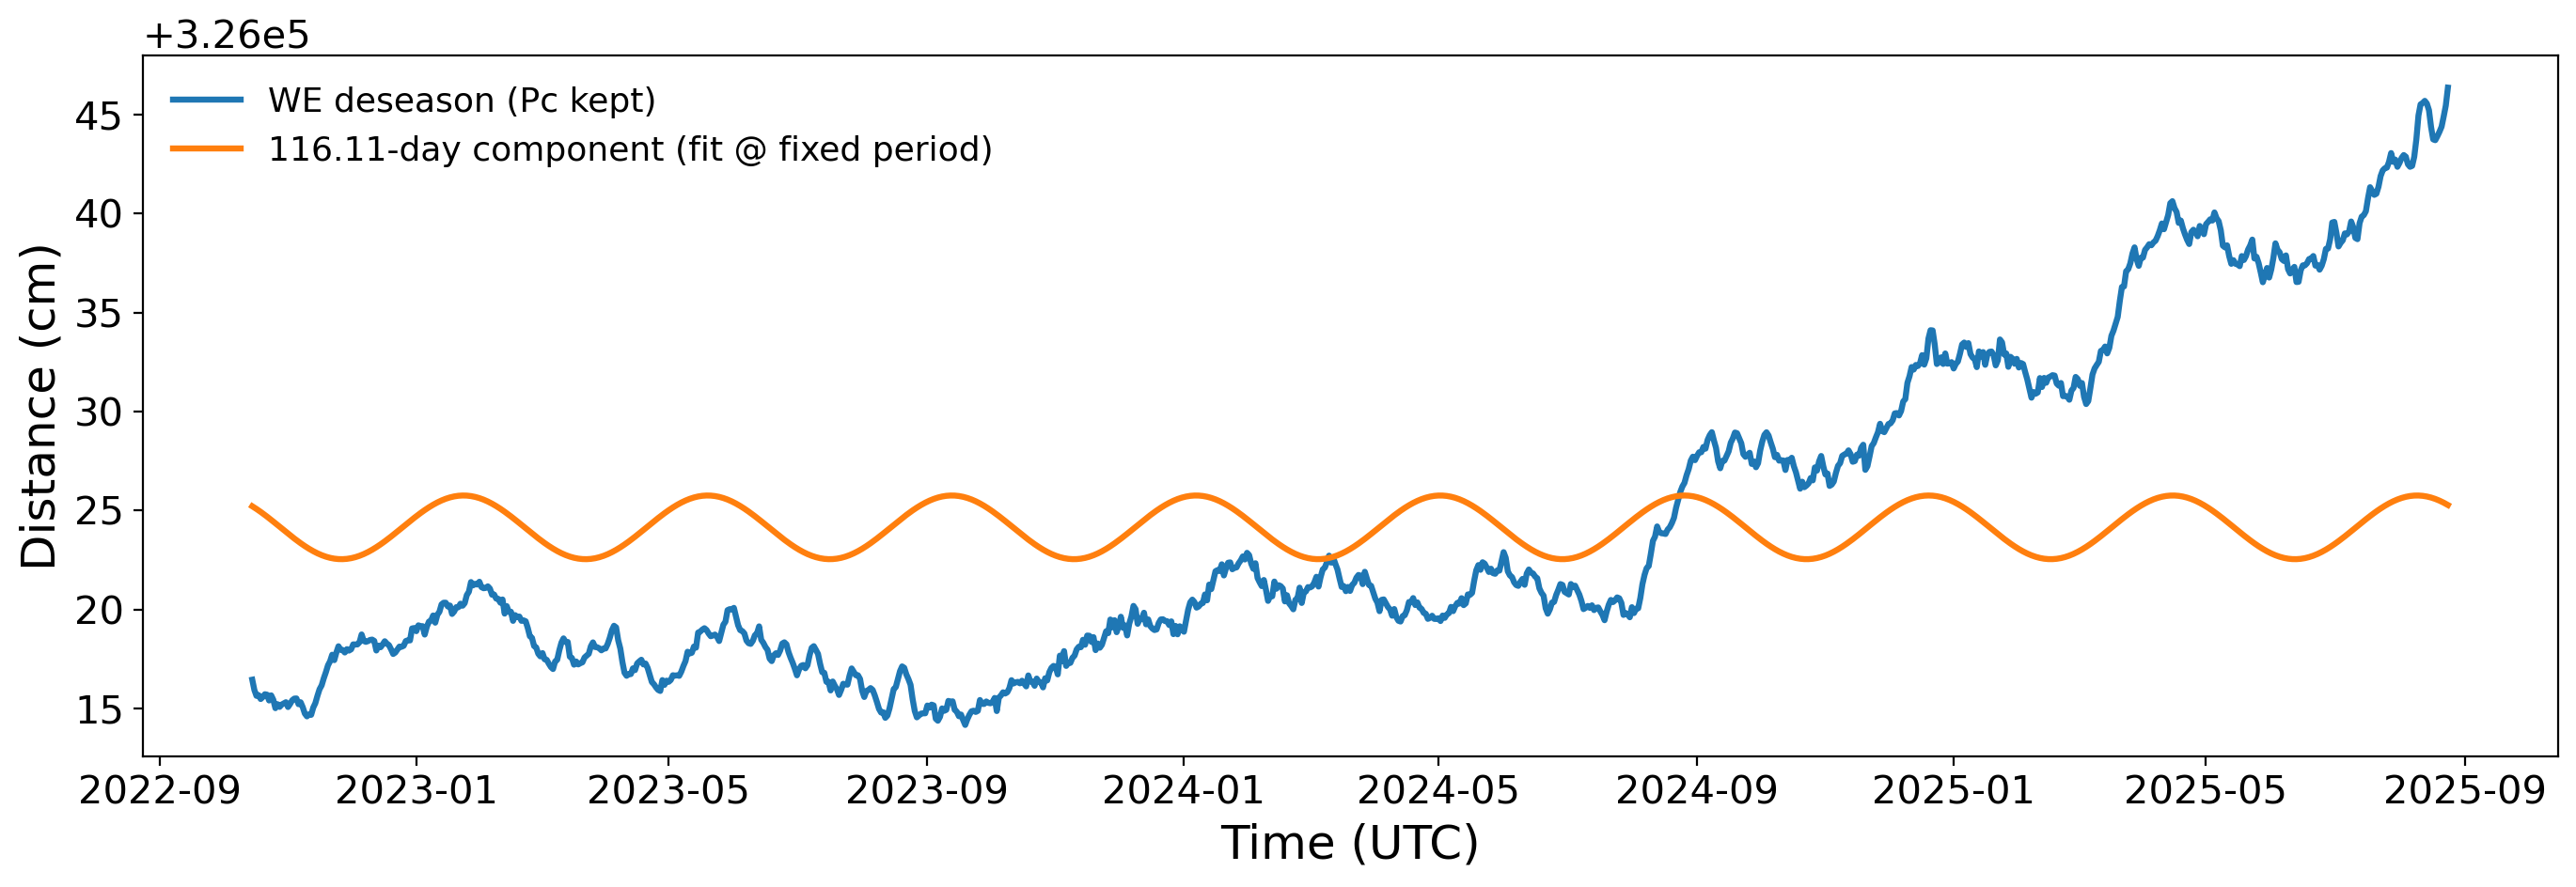

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Plot WE (seasonality removed; Pc kept) and the ~116.11-day signal
# on the SAME axes. No demean, no detrend, no removal.
# ============================================================

TARGET_PERIOD_DAYS = 116.11
f_cpd = 1.0 / TARGET_PERIOD_DAYS
w = 2.0 * np.pi * f_cpd  # rad/day

# ---- 1) Get WE seasonality-removed series ----
if "deseason" in globals() and hasattr(deseason, "columns") and "WE" in deseason.columns:
    we = deseason["WE"].copy()
elif "df" in globals() and "WE_deseason_PcKept" in df.columns:
    we = df["WE_deseason_PcKept"].copy()
else:
    raise KeyError("Need deseason['WE'] or df['WE_deseason_PcKept'].")

# Ensure datetime index
if not isinstance(we.index, pd.DatetimeIndex):
    we.index = pd.to_datetime(we.index, utc=True, errors="coerce")
we = we.dropna().sort_index()

# ---- 2) Uniform daily sampling (so the sinusoid is evaluated cleanly) ----
we_daily = we.resample("1D").mean().interpolate("time").dropna()

# ---- 3) Fit ONLY phase/coeffs at fixed frequency (with intercept) ----
t = np.arange(len(we_daily), dtype=float)  # days since start
y = we_daily.to_numpy().astype(float)

S = np.sin(w * t)
C = np.cos(w * t)
G = np.column_stack([S, C, np.ones_like(t)])  # sin, cos, intercept

coef, *_ = np.linalg.lstsq(G, y, rcond=None)
A, B, c0 = coef

signal_116 = A * S + B * C              # oscillatory component (no intercept)
amp_peak = float(np.sqrt(A*A + B*B))

print(f"116.11-day fitted peak amplitude: {amp_peak:.4f} cm (FFT reported ~1.1346 cm)")

# ---- 4) Plot both on the same axes ----
plt.figure(figsize=(14, 5), dpi=200)
plt.plot(we_daily.index, y, lw=2.3, label="WE deseason (Pc kept)")
#plt.plot(we_daily.index, y-signal_116, lw=2.3, label="oceanography removed")
plt.plot(we_daily.index, signal_116+y.mean(), lw=2.3, label=f"{TARGET_PERIOD_DAYS:.2f}-day component (fit @ fixed period)")
#plt.axhline(0, lw=1.2, ls="--", alpha=0.6)
plt.xlabel("Time (UTC)")
plt.ylabel("Distance (cm)")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


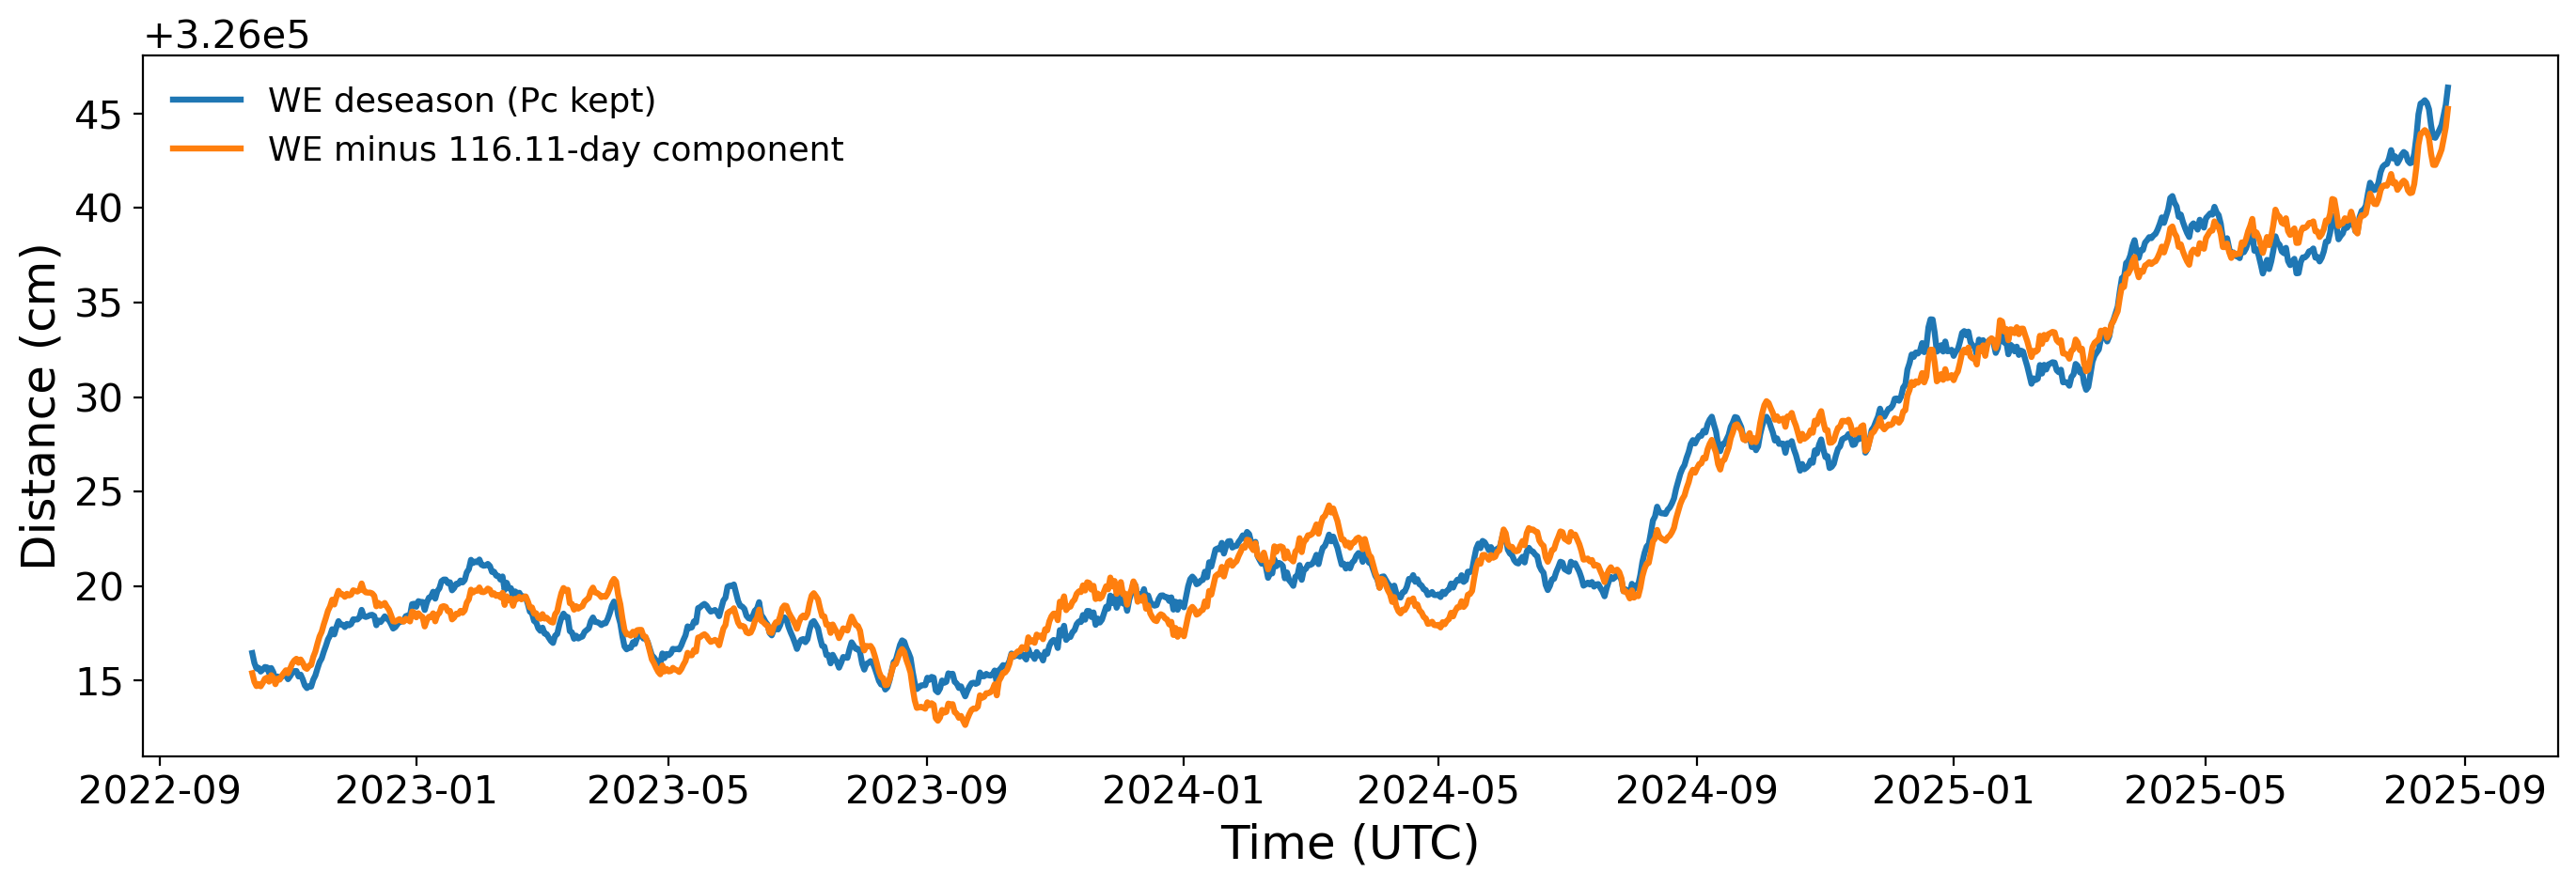

In [54]:
y_removed = y - signal_116

plt.figure(figsize=(14, 5), dpi=200)
plt.plot(we_daily.index, y, lw=2.3, label="WE deseason (Pc kept)")
plt.plot(we_daily.index, y_removed, lw=2.3, label="WE minus 116.11-day component")
#plt.axhline(0, lw=1.2, ls="--", alpha=0.6)
plt.xlabel("Time (UTC)")
plt.ylabel("Distance (cm)")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


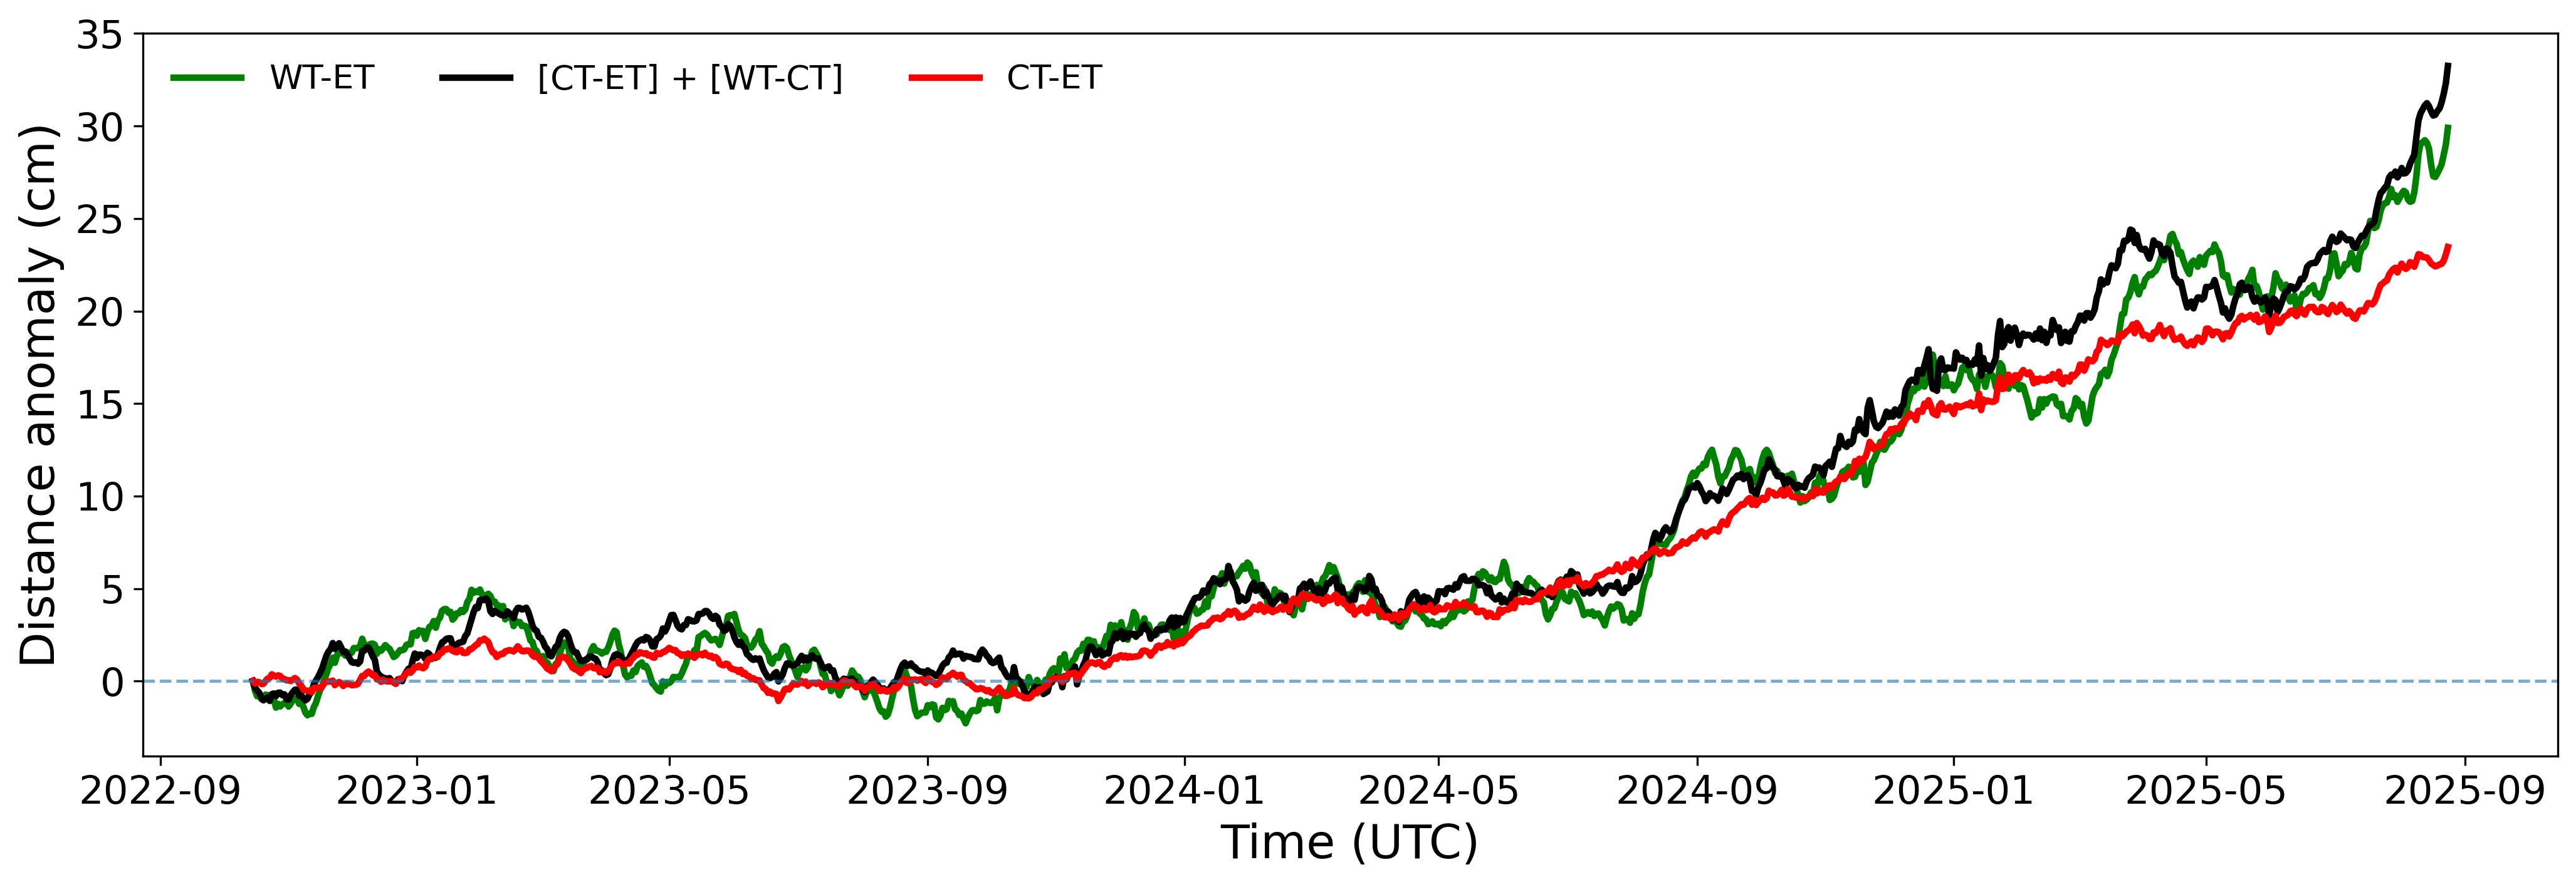

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get seasonality-removed (Pc kept) series for CE/WC/WE
# (works pre-CSV: deseason[...] ; or post-CSV: df["*_deseason_PcKept"])
# ------------------------------------------------------------
def get_deseason_series(name):
    if "deseason" in globals() and hasattr(deseason, "columns") and name in deseason.columns:
        s = deseason[name].copy()
    elif "df" in globals() and f"{name}_deseason_PcKept" in df.columns:
        s = df[f"{name}_deseason_PcKept"].copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            # if df came from CSV and index isn't datetime, try common time columns
            if "Time" in df.columns:
                pass  # already set elsewhere
    else:
        raise KeyError(f"Can't find seasonality-removed series for {name}.")
    # ensure datetime index
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, utc=True, errors="coerce")
    return s.dropna().sort_index()

CE = get_deseason_series("CE")
WC = get_deseason_series("WC")
WE = get_deseason_series("WE")

# Common overlap so they plot cleanly together
idx = CE.index.intersection(WC.index).intersection(WE.index).sort_values()
CE, WC, WE = CE.reindex(idx), WC.reindex(idx), WE.reindex(idx)

# (optional) daily-resample to make curves comparable / smooth gaps
# comment these 3 lines out if you want native sampling
CE = CE.resample("1D").mean().interpolate("time")
WC = WC.resample("1D").mean().interpolate("time")
WE = WE.resample("1D").mean().interpolate("time")
idx = CE.index.intersection(WC.index).intersection(WE.index).sort_values()
CE, WC, WE = CE.reindex(idx), WC.reindex(idx), WE.reindex(idx)

# ------------------------------------------------------------
# Plot (after seasonal removal)
# Choose normalization: from-start or mean-anomaly
# ------------------------------------------------------------
USE_FROM_START = True  # set False to use mean-anomaly

def normalize(s):
    if USE_FROM_START:
        return s - float(s.dropna().iloc[0])
    else:
        return s - float(s.mean())

label_map = {"CE": "CT-ET", "WC": "CT-WT", "WE": "WT-ET"}

plt.figure(figsize=(14, 5), dpi=300)
plt.plot(idx, normalize(WE), lw=2.5, label="WT-ET", color="green")
plt.plot(idx, normalize(CE)+normalize(WC), lw=2.5, label="[CT-ET] + [WT-CT]", color = "black")
plt.plot(idx, normalize(CE), lw=2.5, label="CT-ET", color = "red")


plt.axhline(0, lw=1.2, ls="--", alpha=0.6)
plt.xlabel("Time (UTC)")
plt.ylabel("Distance anomaly (cm)")
plt.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()
